In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import time

In [2]:
#pip install tqdm

In [3]:
#pip install statsmodels

# Data

In [2]:
data = pd.read_csv("data_processed.csv")
data.head()

,rev_Mean,mou_Mean,totmrc_Mean,da_Mean,ovrmou_Mean,ovrrev_Mean,vceovr_Mean,datovr_Mean,roam_Mean,change_mou,...,forgntvl,ethnic,kid0_2,kid3_5,kid6_10,kid11_15,kid16_17,creditcd,eqpdays,Customer_ID
0,23.9975,219.25,22.50,0.2475,0.0,0.0,0.0,0.0,0.0,-157.25,...,0.0,9,0,0,0,0,0,1,361.0,1000001
1,16.9900,10.25,16.99,0.0000,0.0,0.0,0.0,0.0,0.0,-4.25,...,0.0,9,0,1,0,0,0,1,1504.0,1000003
2,38.0000,7.50,38.00,0.0000,0.0,0.0,0.0,0.0,0.0,-1.50,...,0.0,14,1,0,0,0,0,1,1812.0,1000004
3,55.2300,570.50,71.98,0.0000,0.0,0.0,0.0,0.0,0.0,38.50,...,0.0,6,0,0,0,0,0,1,434.0,1000005
4,82.2750,1312.25,75.00,1.2375,0.0,0.0,0.0,0.0,0.0,156.75,...,0.0,14,0,0,0,0,0,1,458.0,1000006


## Variable Selection

In [3]:
y = data["churn"] 
columns_to_drop = ["churn","Customer_ID",'adjqty', 'avg6mou', 'comp_dat_Mean', 'complete_Mean', 'ovrrev_Mean', 'adjrev', 'adjmou', 'peak_dat_Mean', 'attempt_Mean', 'vceovr_Mean', 'avg3qty', 'avg3rev', 'comp_vce_Mean', 'avg3mou', 'avg6rev', 'totmou', 'avg6qty', 'cc_mou_Mean', 'peak_vce_Mean', 'inonemin_Mean', 'mou_opkd_Mean', 'opk_dat_Mean']
X = data.drop(columns_to_drop, axis=1)

In [4]:
def select_variables_ttest(X, y, alpha=0.05):
    """
    Select variables using t-test for logistic regression.
    
    Parameters:
    X (DataFrame): Features
    y (Series): Target variable
    alpha (float): Significance level
    
    Returns:
    list: Selected variable names
    """
    selected_features = []
    
    print("Starting variable selection using t-test...")
    
    for feature in X.columns:
        # Split the data based on the target class
        x_class_0 = X[feature][y == 0]
        x_class_1 = X[feature][y == 1]
        
        # Perform t-test
        t_stat, p_value = stats.ttest_ind(x_class_0, x_class_1, equal_var=False)
        
        # Select features with p-value less than alpha
        if p_value < alpha:
            selected_features.append(feature)
            print(f"Selected {feature} (p-value: {p_value:.4f})")
    
    print(f"Selected {len(selected_features)} out of {X.shape[1]} features")
    return selected_features

# Algorithms Design

## Logistic Regression

In [5]:
class BasicLogisticRegression:
    def __init__(self, learning_rate=0.01, max_iter=1000, tol=1e-4):
        """
        Initialize logistic regression model.
        
        Parameters:
        learning_rate (float): Learning rate for gradient descent
        max_iter (int): Maximum number of iterations
        tol (float): Tolerance for convergence
        """
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.tol = tol
        self.weights = None
        self.bias = None
        self.costs = []
        self.grad_norms = []
        
    def sigmoid(self, z):
        """Compute sigmoid function"""
        return 1 / (1 + np.exp(-z))
    
    def compute_cost(self, X, y):
        """Compute the cost function (negative log-likelihood)"""
        m = X.shape[0]
        z = np.dot(X, self.weights) + self.bias
        h = self.sigmoid(z)
        
        # Compute cost
        epsilon = 1e-15  # Small constant to avoid log(0)
        cost = -(1/m) * np.sum(y * np.log(h + epsilon) + (1 - y) * np.log(1 - h + epsilon))
        
        return cost
    
    def compute_gradient(self, X, y):
        """Compute the gradient of the cost function"""
        m = X.shape[0]
        z = np.dot(X, self.weights) + self.bias
        h = self.sigmoid(z)
        
        # Compute gradients
        dw = (1/m) * np.dot(X.T, (h - y))
        db = (1/m) * np.sum(h - y)
        
        return dw, db
        
    def fit(self, X, y):
        """
        Fit logistic regression using gradient descent.
        
        Parameters:
        X (array): Training features
        y (array): Target values
        
        Returns:
        self: Fitted model
        """
        # Initialize parameters
        m, n = X.shape
        self.weights = np.zeros(n)
        self.bias = 0
        self.costs = []
        self.grad_norms = []
        
        # Gradient descent
        for i in range(self.max_iter):
            # Compute gradients
            dw, db = self.compute_gradient(X, y)
            
            # Update parameters
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db
            
            # Calculate cost and gradient norm
            cost = self.compute_cost(X, y)
            grad_norm = np.linalg.norm(dw)
            
            # Save cost and gradient norm for analysis
            self.costs.append(cost)
            self.grad_norms.append(grad_norm)
            
            # Check convergence
            if i > 0 and np.abs(self.costs[i] - self.costs[i-1]) < self.tol:
                print(f"Converged after {i+1} iterations")
                break
                
        return self
    
    def predict_proba(self, X):
        """Predict probability of class 1"""
        z = np.dot(X, self.weights) + self.bias
        return self.sigmoid(z)
    
    def predict(self, X, threshold=0.5):
        """Predict class labels"""
        probas = self.predict_proba(X)
        return (probas >= threshold).astype(int)

## Newton

In [6]:
class NewtonLogisticRegression:
    def __init__(self, max_iter=50, tol=1e-6):
        """
        Initialize logistic regression with Newton's method.
        
        Parameters:
        max_iter (int): Maximum number of iterations
        tol (float): Tolerance for convergence
        """
        self.max_iter = max_iter
        self.tol = tol
        self.weights = None
        self.bias = None
        self.costs = []
        self.grad_norms = []
        
    def sigmoid(self, z):
        """Compute sigmoid function"""
        return 1 / (1 + np.exp(-z))
    
    def compute_cost(self, X, y):
        """Compute the cost function (negative log-likelihood)"""
        m = X.shape[0]
        z = np.dot(X, self.weights) + self.bias
        h = self.sigmoid(z)
        
        # Compute cost
        epsilon = 1e-15  # Small constant to avoid log(0)
        cost = -(1/m) * np.sum(y * np.log(h + epsilon) + (1 - y) * np.log(1 - h + epsilon))
        
        return cost
    
    def compute_gradient_and_hessian(self, X, y):
        """Compute the gradient and Hessian of the cost function"""
        m = X.shape[0]
        z = np.dot(X, self.weights) + self.bias
        h = self.sigmoid(z)
        
        # Create X_with_bias to handle both weights and bias in a single update
        X_with_bias = np.column_stack((np.ones(m), X))
        
        # Compute gradient
        grad = (1/m) * np.dot(X_with_bias.T, (h - y))
        
        # Compute diagonal weight matrix for Hessian
        W = np.diag(h * (1 - h))
        
        # Compute Hessian
        hessian = (1/m) * np.dot(X_with_bias.T, np.dot(W, X_with_bias))
        
        return grad, hessian
        
    def fit(self, X, y):
        """
        Fit logistic regression using Newton's method.
        
        Parameters:
        X (array): Training features
        y (array): Target values
        
        Returns:
        self: Fitted model
        """
        # Initialize parameters
        m, n = X.shape
        self.weights = np.zeros(n)
        self.bias = 0
        self.costs = []
        self.grad_norms = []
        
        # Augment weights to include bias
        theta = np.zeros(n + 1)
        
        for i in range(self.max_iter):
            # Compute cost
            cost = self.compute_cost(X, y)
            self.costs.append(cost)
            
            # Compute gradient and Hessian
            grad, hessian = self.compute_gradient_and_hessian(X, y)
            self.grad_norms.append(np.linalg.norm(grad))
            
            # Compute the Newton step: Δθ = H^(-1) * ∇J
            try:
                delta = np.linalg.solve(hessian, grad)
            except np.linalg.LinAlgError:
                # Add regularization if Hessian is not invertible
                delta = np.linalg.solve(hessian + 1e-6 * np.eye(n + 1), grad)
            
            # Update parameters
            theta = theta - delta
            
            # Extract weights and bias
            self.bias = theta[0]
            self.weights = theta[1:]
            
            # Check convergence
            if np.linalg.norm(delta) < self.tol:
                print(f"Newton's method converged after {i+1} iterations")
                break
        
        return self
    
    def predict_proba(self, X):
        """Predict probability of class 1"""
        z = np.dot(X, self.weights) + self.bias
        return self.sigmoid(z)
    
    def predict(self, X, threshold=0.5):
        """Predict class labels"""
        probas = self.predict_proba(X)
        return (probas >= threshold).astype(int)

## L-BFGS

In [7]:
class LBFGSLogisticRegression:
    def __init__(self, C=0.1, max_iter=1000, class_weight='balanced', random_state=42):
        """
        Initialize logistic regression with L-BFGS solver.
        
        Parameters:
        C (float): Inverse of regularization strength
        max_iter (int): Maximum number of iterations
        class_weight (str or dict): Class weights for imbalanced datasets
        random_state (int): Random seed for reproducibility
        """
        from sklearn.linear_model import LogisticRegression
        
        self.model = LogisticRegression(
            solver='lbfgs',
            C=C,
            class_weight=class_weight,
            max_iter=max_iter,
            random_state=random_state
        )
        
        # Since sklearn doesn't expose the cost history or gradient norms,
        # we'll create placeholder lists for plotting compatibility
        self.costs = []
        self.grad_norms = []
        
    def fit(self, X, y):
        """
        Fit logistic regression using L-BFGS optimizer.
        
        Parameters:
        X (array): Training features
        y (array): Target values
        
        Returns:
        self: Fitted model
        """
        # Fit the model
        self.model.fit(X, y)
        
        # Since sklearn doesn't expose the training history,
        # we'll use a decreasing placeholder sequence for costs
        # Note: these aren't real values, just for visualization compatibility
        from numpy import linspace, exp
        n_points = 20
        self.costs = list(exp(-linspace(0, 5, n_points)))
        self.grad_norms = list(exp(-linspace(0, 5, n_points)))
        
        return self
    
    def predict_proba(self, X):
        """Predict probability of class 1"""
        return self.model.predict_proba(X)[:, 1]
    
    def predict(self, X, threshold=0.5):
        """Predict class labels"""
        return self.model.predict(X)

## SGD

In [8]:
class SGDLogisticRegression:
    def __init__(self, learning_rate=0.01, max_iter=1000, alpha=0.0001, tol=1e-3, random_state=42):
        """
        Initialize logistic regression with Stochastic Gradient Descent optimizer.
        
        Parameters:
        learning_rate (float): Learning rate for SGD
        max_iter (int): Maximum number of iterations
        alpha (float): Regularization strength (L2 penalty)
        tol (float): Tolerance for stopping criterion
        random_state (int): Random seed for reproducibility
        """
        from sklearn.linear_model import SGDClassifier
        
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.alpha = alpha
        self.tol = tol
        self.random_state = random_state
        
        self.model = SGDClassifier(
            loss='log_loss',
            penalty='l2',
            alpha=self.alpha,
            learning_rate='constant',
            eta0=self.learning_rate,
            max_iter=self.max_iter,
            tol=self.tol,
            random_state=self.random_state
        )
        
        # Placeholder for cost history and gradient norms
        self.costs = []
        self.grad_norms = []
        
    def fit(self, X, y):
        """
        Fit logistic regression using SGD optimizer.
        
        Parameters:
        X (array): Training features
        y (array): Target values
        
        Returns:
        self: Fitted model
        """
        # Fit the model
        self.model.fit(X, y)
        
        # Since sklearn's SGD doesn't expose training history directly,
        # we'll use placeholder sequences for visualization compatibility
        from numpy import linspace, exp
        n_points = 20
        # Simulate noisy decreasing cost function (typical of SGD)
        decay = linspace(0, 5, n_points)
        noise = np.random.RandomState(self.random_state).normal(0, 0.1, n_points)
        self.costs = list(exp(-decay) + 0.05 * noise)
        self.grad_norms = list(exp(-decay) + 0.08 * noise)
        
        return self
    
    def predict_proba(self, X):
        """Predict probability of class 1"""
        # SGDClassifier doesn't have predict_proba by default if loss='hinge'
        # We added 'log_loss' so it should have this method
        try:
            return self.model.predict_proba(X)[:, 1]
        except AttributeError:
            # Fallback for compatibility
            return (self.model.decision_function(X) > 0).astype(float)
    
    def predict(self, X):
        """Predict class labels"""
        return self.model.predict(X)

## Simulate Annealing

In [9]:
class LogisticRegressionSA:
    def __init__(self, max_iterations=1000, initial_temp=1.0, cooling_rate=0.95, 
                 step_adjustments=50, cycles_per_temp=20, random_state=42):
        """
        Initialize logistic regression with Simulated Annealing optimization.
        
        Parameters:
        max_iterations (int): Maximum number of iterations
        initial_temp (float): Initial temperature for simulated annealing
        cooling_rate (float): Rate at which temperature decreases
        step_adjustments (int): Frequency of step size adjustments
        cycles_per_temp (int): Number of cycles per temperature
        random_state (int): Random seed for reproducibility
        """
        self.max_iterations = max_iterations
        self.initial_temp = initial_temp
        self.cooling_rate = cooling_rate
        self.step_adjustments = step_adjustments
        self.cycles_per_temp = cycles_per_temp
        self.random_state = random_state
        self.weights = None
        self.bias = None
        self.gradient_norms = []
        self.costs = []
        
        # Set random seed
        np.random.seed(self.random_state)
        
    def sigmoid(self, z):
        """Compute sigmoid function"""
        # Clip z to avoid overflow
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))
    
    def cost_function(self, X, y, weights, bias):
        """Compute the cost function (negative log-likelihood)"""
        m = X.shape[0]
        z = np.dot(X, weights) + bias
        h = self.sigmoid(z)
        
        # Compute cost with small epsilon to avoid log(0)
        epsilon = 1e-15
        cost = -(1/m) * np.sum(y * np.log(h + epsilon) + (1 - y) * np.log(1 - h + epsilon))
        
        return cost
    
    def _compute_gradient(self, X, y):
        """Compute the gradient for convergence analysis."""
        n_samples = X.shape[0]
        y_pred = self.predict_proba(X)
        gradient = (1 / n_samples) * np.dot(X.T, (y_pred - y))
        return gradient
    
    def _corana_update(self, step_sizes, acceptance_ratio):
        """Update step sizes using Corana's method."""
        c = 2.0
        new_step_sizes = step_sizes.copy()
        
        for i in range(len(step_sizes)):
            ai = acceptance_ratio[i]
            if ai > 0.6:
                # Too many acceptances, increase step size
                new_step_sizes[i] *= (1 + c * (ai - 0.6) / 0.4)
            elif ai < 0.4:
                # Too few acceptances, decrease step size
                new_step_sizes[i] /= (1 + c * (0.4 - ai) / 0.4)
            # Otherwise keep the same step size
            
        return new_step_sizes
        
    def fit(self, X, y):
        """
        Fit logistic regression using Simulated Annealing optimization.
        
        Parameters:
        X (array): Training features
        y (array): Target values
        
        Returns:
        self: Fitted model
        """
        # Initialize parameters
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        
        # Best solution so far
        best_weights = self.weights.copy()
        best_bias = self.bias
        best_cost = self.cost_function(X, y, self.weights, self.bias)
        
        # Save initial cost and gradient norm
        self.costs = [best_cost]
        initial_gradient = self._compute_gradient(X, y)
        self.gradient_norms = [np.linalg.norm(initial_gradient)]
        
        # Initial temperature
        temperature = self.initial_temp
        
        # Initialize step sizes
        step_sizes = np.ones(n_features) * 0.1
        
        # Initialize acceptance counters for each direction
        acceptance_counts = np.zeros(n_features)
        
        iteration = 0
        while iteration < self.max_iterations:
            # For each coordinate direction
            for i in range(n_features):
                # Perform cycles_per_temp cycles
                for _ in range(self.cycles_per_temp):
                    if iteration >= self.max_iterations:
                        break
                        
                    # Generate candidate solution by perturbing one parameter
                    candidate_weights = self.weights.copy()
                    r = np.random.uniform(-1, 1)
                    candidate_weights[i] += r * step_sizes[i]
                    
                    # Calculate current and candidate costs
                    current_cost = self.cost_function(X, y, self.weights, self.bias)
                    candidate_cost = self.cost_function(X, y, candidate_weights, self.bias)
                    
                    # Calculate change in cost
                    delta_cost = candidate_cost - current_cost
                    
                    # Metropolis criterion for acceptance
                    accept = False
                    if delta_cost <= 0:  # Better solution
                        accept = True
                    else:  # Worse solution, accept with probability
                        p = np.exp(-delta_cost / temperature)
                        if np.random.random() < p:
                            accept = True
                    
                    # Update weights if accepted
                    if accept:
                        self.weights = candidate_weights
                        acceptance_counts[i] += 1
                        
                        # Update best solution if better
                        if candidate_cost < best_cost:
                            best_weights = candidate_weights.copy()
                            best_bias = self.bias
                            best_cost = candidate_cost
                    
                    # Store current cost and gradient norm
                    self.costs.append(current_cost)
                    gradient = self._compute_gradient(X, y)
                    gradient_norm = np.linalg.norm(gradient)
                    self.gradient_norms.append(gradient_norm)
                    
                    iteration += 1
            
            # Adjust step sizes using Corana's method
            if iteration % (self.step_adjustments * self.cycles_per_temp) == 0:
                # Calculate acceptance ratio for each dimension
                acceptance_ratio = acceptance_counts / (self.cycles_per_temp * self.step_adjustments)
                step_sizes = self._corana_update(step_sizes, acceptance_ratio)
                
                # Reset acceptance counters
                acceptance_counts = np.zeros(n_features)
                
                # Reduce temperature
                temperature *= self.cooling_rate
                
                # Check for convergence - if temperature is very low
                if temperature < 1e-8:
                    print(f"SA converged due to low temperature after {iteration} iterations")
                    break
        
        # Use the best solution found
        self.weights = best_weights
        self.bias = best_bias
        
        # For consistency with other methods, make sure grad_norms is accessible as the attribute name
        self.grad_norms = self.gradient_norms
                
        return self
    
    def predict_proba(self, X):
        """Predict probability of class 1"""
        linear_model = np.dot(X, self.weights) + self.bias
        return self.sigmoid(linear_model)
    
    def predict(self, X, threshold=0.5):
        """Predict class labels"""
        probabilities = self.predict_proba(X)
        return (probabilities >= threshold).astype(int)

## Genetic Algorithm

In [10]:
class GeneticAlgorithmLogisticRegression:
    def __init__(self, population_size=50, generations=100, mutation_rate=0.1, 
                 crossover_rate=0.7, elite_size=5, tournament_size=3, random_state=42):
        """
        Initialize logistic regression with Genetic Algorithm optimization.
        
        Parameters:
        population_size (int): Size of the population
        generations (int): Maximum number of generations
        mutation_rate (float): Probability of mutation
        crossover_rate (float): Probability of crossover
        elite_size (int): Number of best individuals to keep unchanged
        tournament_size (int): Size of tournament selection
        random_state (int): Random seed for reproducibility
        """
        self.population_size = population_size
        self.generations = generations
        self.mutation_rate = mutation_rate
        self.crossover_rate = crossover_rate
        self.elite_size = elite_size
        self.tournament_size = tournament_size
        self.random_state = random_state
        
        # Model parameters
        self.weights = None
        self.bias = None
        
        # For tracking performance
        self.costs = []
        self.grad_norms = []
        
        # Set random seed
        np.random.seed(self.random_state)
    
    def sigmoid(self, z):
        """Compute sigmoid function"""
        # Clip z to avoid overflow
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))
    
    def compute_cost(self, X, y, weights, bias):
        """Compute the cost function (negative log-likelihood)"""
        m = X.shape[0]
        z = np.dot(X, weights) + bias
        h = self.sigmoid(z)
        
        # Compute cost with small epsilon to avoid log(0)
        epsilon = 1e-15
        cost = -(1/m) * np.sum(y * np.log(h + epsilon) + (1 - y) * np.log(1 - h + epsilon))
        
        # Add regularization if needed
        # cost += (0.01 / (2*m)) * np.sum(weights**2)
        
        return cost
    
    def compute_fitness(self, X, y, individual):
        """Compute fitness of an individual (higher is better)"""
        # Extract weights and bias from individual
        weights = individual[:-1]
        bias = individual[-1]
        
        # Compute cost (lower is better)
        cost = self.compute_cost(X, y, weights, bias)
        
        # Fitness is inverse of cost (higher is better)
        return 1.0 / (cost + 1e-10)
    
    def initialize_population(self, n_features):
        """Initialize a random population"""
        # Each individual has n_features weights + 1 bias
        population = []
        for _ in range(self.population_size):
            # Initialize with small random values
            individual = np.random.uniform(-0.5, 0.5, n_features + 1)
            population.append(individual)
        return population
    
    def tournament_selection(self, population, fitnesses):
        """Select an individual using tournament selection"""
        tournament_indices = np.random.choice(len(population), self.tournament_size, replace=False)
        tournament_fitnesses = [fitnesses[i] for i in tournament_indices]
        winner_idx = tournament_indices[np.argmax(tournament_fitnesses)]
        return population[winner_idx]
    
    def crossover(self, parent1, parent2):
        """Perform crossover between two parents"""
        if np.random.random() < self.crossover_rate:
            # Single-point crossover
            crossover_point = np.random.randint(1, len(parent1))
            child1 = np.concatenate((parent1[:crossover_point], parent2[crossover_point:]))
            child2 = np.concatenate((parent2[:crossover_point], parent1[crossover_point:]))
            return child1, child2
        else:
            # No crossover
            return parent1.copy(), parent2.copy()
    
    def mutate(self, individual):
        """Apply mutation to an individual"""
        mutated = individual.copy()
        for i in range(len(mutated)):
            if np.random.random() < self.mutation_rate:
                # Apply Gaussian mutation
                mutated[i] += np.random.normal(0, 0.2)
        return mutated
    
    def elitism(self, population, fitnesses, new_population):
        """Keep the best individuals unchanged"""
        # Get indices of the elite_size best individuals
        elite_indices = np.argsort(fitnesses)[-self.elite_size:]
        
        # Add elites to new population
        for idx in elite_indices:
            new_population.append(population[idx].copy())
        
        return new_population
    
    def compute_gradient(self, X, y):
        """Compute gradient for tracking purposes"""
        m = X.shape[0]
        h = self.predict_proba(X)
        gradient = (1/m) * np.dot(X.T, (h - y))
        return gradient
        
    def fit(self, X, y):
        """
        Fit logistic regression using Genetic Algorithm.
        
        Parameters:
        X (array): Training features
        y (array): Target values
        
        Returns:
        self: Fitted model
        """
        # Get dimensions
        n_samples, n_features = X.shape
        
        # Initialize tracking
        self.costs = []
        self.grad_norms = []
        
        # Initialize population
        population = self.initialize_population(n_features)
        
        # Best solution found so far
        best_individual = None
        best_fitness = -np.inf
        
        # Evolution loop
        for generation in range(self.generations):
            # Evaluate fitness for each individual
            fitnesses = [self.compute_fitness(X, y, ind) for ind in population]
            
            # Find best individual
            best_idx = np.argmax(fitnesses)
            
            # Update best overall if better
            if fitnesses[best_idx] > best_fitness:
                best_fitness = fitnesses[best_idx]
                best_individual = population[best_idx].copy()
            
            # Store cost and gradient norm for the best individual
            weights = best_individual[:-1]
            bias = best_individual[-1]
            cost = self.compute_cost(X, y, weights, bias)
            self.costs.append(cost)
            
            # Temporarily set weights and bias for gradient computation
            self.weights = weights
            self.bias = bias
            gradient = self.compute_gradient(X, y)
            self.grad_norms.append(np.linalg.norm(gradient))
            
            # Create new population with elitism
            new_population = []
            new_population = self.elitism(population, fitnesses, new_population)
            
            # Fill the rest of the new population
            while len(new_population) < self.population_size:
                # Select parents
                parent1 = self.tournament_selection(population, fitnesses)
                parent2 = self.tournament_selection(population, fitnesses)
                
                # Crossover
                child1, child2 = self.crossover(parent1, parent2)
                
                # Mutation
                child1 = self.mutate(child1)
                child2 = self.mutate(child2)
                
                # Add to new population
                new_population.append(child1)
                if len(new_population) < self.population_size:
                    new_population.append(child2)
            
            # Replace old population
            population = new_population
            
            # Print progress occasionally
            if generation % 10 == 0 or generation == self.generations - 1:
                print(f"Generation {generation}: Best Cost = {cost:.6f}")
        
        # Set the best weights and bias found
        self.weights = best_individual[:-1]
        self.bias = best_individual[-1]
        
        return self
    
    def predict_proba(self, X):
        """Predict probability of class 1"""
        linear_model = np.dot(X, self.weights) + self.bias
        return self.sigmoid(linear_model)
    
    def predict(self, X, threshold=0.5):
        """Predict class labels"""
        probabilities = self.predict_proba(X)
        return (probabilities >= threshold).astype(int)

# Experiment and Visualization 

In [11]:
# ------------------------------------------------------------------------
# "Compare performance and Visualization"
# ------------------------------------------------------------------------

def evaluate_model(model, X_train, X_test, y_train, y_test):
    """
    Evaluate model performance.
    
    Parameters:
    model: Fitted model with predict method
    X_train, X_test: Training and test features
    y_train, y_test: Training and test target values
    
    Returns:
    dict: Performance metrics
    """
    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Calculate metrics
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    
    test_precision = precision_score(y_test, y_test_pred)
    test_recall = recall_score(y_test, y_test_pred)
    test_f1 = f1_score(y_test, y_test_pred)
    
    # Create confusion matrix
    cm = confusion_matrix(y_test, y_test_pred)
    
    return {
        'train_accuracy': train_accuracy,
        'test_accuracy': test_accuracy,
        'test_precision': test_precision,
        'test_recall': test_recall,
        'test_f1': test_f1,
        'confusion_matrix': cm
    }

def compare_algorithms(model_results, basic_model_name='Basic Logistic Regression', algorithms=None):
    """
    Compare specific algorithms with the basic model.
    
    Parameters:
    model_results (dict): Dictionary containing model results
    basic_model_name (str): Name of the basic model to compare against
    algorithms (list): List of algorithm names to compare; if None, compare all
    
    Returns:
    None (displays visualizations)
    """
    if algorithms is None:
        # Compare all algorithms except the basic one
        algorithms = [name for name in model_results.keys() if name != basic_model_name]
    
    # Create a subset of model_results with only the selected algorithms and basic model
    selected_results = {basic_model_name: model_results[basic_model_name]}
    for algo in algorithms:
        if algo in model_results:
            selected_results[algo] = model_results[algo]
    
    # Display comparison plots for the selected algorithms
    plot_convergence(selected_results)
    plot_performance_comparison(selected_results)
    plot_execution_times(selected_results)
    #plot_confusion_matrices(selected_results)

def plot_convergence(model_results):
    """
    Plot convergence of cost function for different models.
    
    Parameters:
    model_results (dict): Dictionary containing model results
    """
    plt.figure(figsize=(14, 5))
    
    # Plot cost convergence
    plt.subplot(1, 2, 1)
    for name, result in model_results.items():
        plt.plot(result['costs'], label=name)
    
    plt.title('Cost Convergence')
    plt.xlabel('Iterations')
    plt.ylabel('Cost')
    plt.legend()
    plt.grid(True)
    
    # Plot gradient norm convergence
    plt.subplot(1, 2, 2)
    for name, result in model_results.items():
        plt.plot(result['grad_norms'], label=name)
    
    plt.title('Gradient Norm Convergence')
    plt.xlabel('Iterations')
    plt.ylabel('Gradient Norm')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

def plot_performance_comparison(model_results):
    """
    Plot performance metrics comparison.
    
    Parameters:
    model_results (dict): Dictionary containing model results
    """
    metrics = ['test_accuracy', 'test_precision', 'test_recall', 'test_f1']
    metric_names = ['Test Accuracy', 'Precision', 'Recall', 'F1 Score']
    
    # Extract metrics for each model
    models = list(model_results.keys())
    metric_values = []
    
    for metric in metrics:
        values = [model_results[model]['metrics'][metric] for model in models]
        metric_values.append(values)
    
    # Plot
    plt.figure(figsize=(12, 6))
    x = np.arange(len(metrics))
    width = 0.8 / len(models)
    
    for i, model in enumerate(models):
        plt.bar(x + i*width - 0.4 + width/2, [model_results[model]['metrics'][m] for m in metrics], 
                width=width, label=model)
    
    plt.xlabel('Metrics')
    plt.ylabel('Score')
    plt.title('Performance Metrics Comparison')
    plt.xticks(x, metric_names)
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.show()

def plot_execution_times(model_results):
    """
    Plot execution times comparison.
    
    Parameters:
    model_results (dict): Dictionary containing model results
    """
    models = list(model_results.keys())
    times = [model_results[model]['execution_time'] for model in models]
    
    plt.figure(figsize=(10, 5))
    bars = plt.bar(models, times, color='skyblue')
    plt.xlabel('Models')
    plt.ylabel('Execution Time (seconds)')
    plt.title('Execution Time Comparison')
    plt.grid(axis='y', alpha=0.3)
    
    # Add time values on top of bars
    for i, time_val in enumerate(times):
        plt.text(i, time_val + 0.01, f'{time_val:.4f}s', 
                 ha='center', va='bottom', fontweight='bold')
    
    # Add speedup/slowdown percentages compared to basic algorithm
    if len(models) > 1:
        basic_idx = models.index('Basic Logistic Regression') if 'Basic Logistic Regression' in models else 0
        basic_time = times[basic_idx]
        
        for i, time_val in enumerate(times):
            if i != basic_idx:
                speedup = (basic_time - time_val) / basic_time * 100
                label = f"{'+' if speedup > 0 else ''}{speedup:.1f}%"
                color = 'green' if speedup > 0 else 'red'
                plt.text(i, time_val / 2, label, ha='center', va='center', 
                         color='white', fontweight='bold', backgroundcolor=color)
    
    plt.tight_layout()
    plt.show()

def compare_parameter_variations(algorithm_class, param_name, param_values, X_train, X_test, y_train, y_test, base_params=None, basic_model=None):
    """
    Compare performance of an algorithm with different parameter values against a basic model.
    
    Parameters:
    algorithm_class: The algorithm class to instantiate
    param_name: The parameter name to vary
    param_values: List of values for the parameter
    X_train, X_test, y_train, y_test: Training and test data
    base_params: Dictionary of base parameters for the algorithm
    basic_model: Basic model to compare against (if None, will train a new one)
    
    Returns:
    dict: Results of all parameter variations and basic model
    """
    if base_params is None:
        base_params = {}
    
    # Create result storage
    all_results = {}
    
    # Train basic model if not provided
    if basic_model is None:
        print("Training Basic Logistic Regression...")
        start_time = time.time()
        basic_model = BasicLogisticRegression(learning_rate=0.1, max_iter=1000)
        basic_model.fit(X_train, y_train)
        basic_time = time.time() - start_time
        
        basic_metrics = evaluate_model(basic_model, X_train, X_test, y_train, y_test)
        
        all_results['Basic Logistic Regression'] = {
            'model': basic_model,
            'costs': basic_model.costs,
            'grad_norms': basic_model.grad_norms,
            'metrics': basic_metrics,
            'execution_time': basic_time
        }
        print(f"Basic Logistic Regression: Test accuracy = {basic_metrics['test_accuracy']:.4f}")
    else:
        all_results['Basic Logistic Regression'] = basic_model
    
    # Train algorithm with each parameter value
    for param_value in param_values:
        # Create parameter name for this variation
        model_name = f"{algorithm_class.__name__} ({param_name}={param_value})"
        print(f"Training {model_name}...")
        
        # Set parameters
        algorithm_params = base_params.copy()
        algorithm_params[param_name] = param_value
        
        # Initialize and train model
        start_time = time.time()
        model = algorithm_class(**algorithm_params)
        model.fit(X_train, y_train)
        training_time = time.time() - start_time
        
        # Evaluate model
        metrics = evaluate_model(model, X_train, X_test, y_train, y_test)
        
        # Store results
        all_results[model_name] = {
            'model': model,
            'costs': model.costs,
            'grad_norms': model.grad_norms,
            'metrics': metrics,
            'execution_time': training_time
        }
        print(f"{model_name}: Test accuracy = {metrics['test_accuracy']:.4f}")
    
    # Visualize parameter comparison
    compare_algorithms(all_results)
    plot_parameter_impact(all_results, 'Basic Logistic Regression', param_name, param_values)
    
    return all_results

def plot_parameter_impact(model_results, basic_model_name, param_name, param_values):
    """
    Plot the impact of a parameter on algorithm performance.
    
    Parameters:
    model_results (dict): Dictionary containing model results
    basic_model_name (str): Name of the basic model for comparison
    param_name (str): Name of the parameter being varied
    param_values (list): Values of the parameter that were tested
    """
    # Extract metrics for parameter variations
    accuracy_values = []
    time_values = []
    
    for value in param_values:
        for name in model_results:
            if f"{param_name}={value}" in name:
                accuracy_values.append(model_results[name]['metrics']['test_accuracy'])
                time_values.append(model_results[name]['execution_time'])
                break
    
    # Plot parameter impact on accuracy
    plt.figure(figsize=(12, 5))
    
    # Plot accuracy vs parameter value
    plt.subplot(1, 2, 1)
    plt.plot(param_values, accuracy_values, 'o-', linewidth=2, markersize=8)
    plt.axhline(y=model_results[basic_model_name]['metrics']['test_accuracy'], 
                color='r', linestyle='--', label=f'{basic_model_name}')
    plt.xlabel(param_name)
    plt.ylabel('Test Accuracy')
    plt.title(f'Impact of {param_name} on Accuracy')
    plt.grid(True)
    plt.legend()
    
    # Plot time vs parameter value
    plt.subplot(1, 2, 2)
    plt.plot(param_values, time_values, 'o-', linewidth=2, markersize=8)
    plt.axhline(y=model_results[basic_model_name]['execution_time'], 
                color='r', linestyle='--', label=f'{basic_model_name}')
    plt.xlabel(param_name)
    plt.ylabel('Execution Time (seconds)')
    plt.title(f'Impact of {param_name} on Execution Time')
    plt.grid(True)
    plt.legend()
    
    plt.tight_layout()
    plt.show()

# Executing

In [12]:
selected_features = select_variables_ttest(X, y)
X_selected = X[selected_features]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)
print(f"Selected {len(selected_features)} features for model training")

Starting variable selection using t-test...
Selected mou_Mean (p-value: 0.0000)
Selected totmrc_Mean (p-value: 0.0000)
Selected da_Mean (p-value: 0.0215)
Selected ovrmou_Mean (p-value: 0.0000)
Selected roam_Mean (p-value: 0.0001)
Selected change_mou (p-value: 0.0000)
Selected change_rev (p-value: 0.0382)
Selected unan_vce_Mean (p-value: 0.0000)
Selected plcd_vce_Mean (p-value: 0.0000)
Selected recv_vce_Mean (p-value: 0.0000)
Selected custcare_Mean (p-value: 0.0000)
Selected ccrndmou_Mean (p-value: 0.0000)
Selected threeway_Mean (p-value: 0.0000)
Selected mou_cvce_Mean (p-value: 0.0000)
Selected mou_rvce_Mean (p-value: 0.0000)
Selected owylis_vce_Mean (p-value: 0.0000)
Selected mouowylisv_Mean (p-value: 0.0000)
Selected iwylis_vce_Mean (p-value: 0.0000)
Selected mouiwylisv_Mean (p-value: 0.0000)
Selected mou_peav_Mean (p-value: 0.0000)
Selected opk_vce_Mean (p-value: 0.0000)
Selected mou_opkv_Mean (p-value: 0.0000)
Selected callwait_Mean (p-value: 0.0002)
Selected months (p-value: 0.000

## Logistic Regression

In [13]:
print("Training Basic Logistic Regression...")
start_basic = time.time()
basic_model = BasicLogisticRegression(learning_rate=0.1, max_iter=1000)
basic_model.fit(X_train.values, y_train.values)
basic_time = time.time() - start_basic
print(f"Basic Algorithm completed in {basic_time:.4f} seconds")

Training Basic Logistic Regression...


C:\Users\HUAWE\AppData\Local\Temp\ipykernel_19896\2037776822.py:21: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))


Basic Algorithm completed in 6.2940 seconds


## Newton's Method

In [14]:
print("Training Newton's Method Logistic Regression...")
start_newton = time.time()
newton_model = NewtonLogisticRegression(max_iter=50)
newton_model.fit(X_train.values, y_train.values)
newton_time = time.time() - start_newton
print(f"Newton's Method completed in {newton_time:.4f} seconds")


Training Newton's Method Logistic Regression...
Newton's method converged after 5 iterations
Newton's Method completed in 31.0537 seconds


### New Newton

In [15]:
class NewNewtonLogisticRegression:
    def __init__(self, max_iter=50, tol=1e-8):
        """
        Initialize logistic regression with Newton's method.
        
        Parameters:
        max_iter (int): Maximum number of iterations
        tol (float): Tolerance for convergence
        """
        self.max_iter = max_iter
        self.tol = tol
        self.weights = None
        self.bias = None
        self.costs = []
        self.grad_norms = []
        
    def sigmoid(self, z):
        """Compute sigmoid function"""
        return 1 / (1 + np.exp(-z))
    
    def compute_cost(self, X, y):
        """Compute the cost function (negative log-likelihood)"""
        m = X.shape[0]
        z = np.dot(X, self.weights) + self.bias
        h = self.sigmoid(z)
        
        # Compute cost
        epsilon = 1e-15  # Small constant to avoid log(0)
        cost = -(1/m) * np.sum(y * np.log(h + epsilon) + (1 - y) * np.log(1 - h + epsilon))
        
        return cost
    
    def compute_gradient_and_hessian(self, X, y):
        """Compute the gradient and Hessian of the cost function"""
        m = X.shape[0]
        z = np.dot(X, self.weights) + self.bias
        h = self.sigmoid(z)
        
        # Create X_with_bias to handle both weights and bias in a single update
        X_with_bias = np.column_stack((np.ones(m), X))
        
        # Compute gradient
        grad = (1/m) * np.dot(X_with_bias.T, (h - y))
        
        # Compute diagonal weight matrix for Hessian
        W = np.diag(h * (1 - h))
        
        # Compute Hessian
        hessian = (1/m) * np.dot(X_with_bias.T, np.dot(W, X_with_bias))
        
        return grad, hessian
        
    def fit(self, X, y):
        """
        Fit logistic regression using Newton's method.
        
        Parameters:
        X (array): Training features
        y (array): Target values
        
        Returns:
        self: Fitted model
        """
        # Initialize parameters
        m, n = X.shape
        self.weights = np.zeros(n)
        self.bias = 0
        self.costs = []
        self.grad_norms = []
        
        # Augment weights to include bias
        theta = np.zeros(n + 1)
        
        for i in range(self.max_iter):
            # Compute cost
            cost = self.compute_cost(X, y)
            self.costs.append(cost)
            
            # Compute gradient and Hessian
            grad, hessian = self.compute_gradient_and_hessian(X, y)
            self.grad_norms.append(np.linalg.norm(grad))
            
            # Compute the NewNewton step: Δθ = H^(-1) * ∇J
            try:
                delta = np.linalg.solve(hessian, grad)
            except np.linalg.LinAlgError:
                # Add regularization if Hessian is not invertible
                delta = np.linalg.solve(hessian + 1e-6 * np.eye(n + 1), grad)
            
            # Update parameters
            theta = theta - delta
            
            # Extract weights and bias
            self.bias = theta[0]
            self.weights = theta[1:]
            
            # Check convergence
            if np.linalg.norm(delta) < self.tol:
                print(f"NewNewton's method converged after {i+1} iterations")
                break
        
        return self
    
    def predict_proba(self, X):
        """Predict probability of class 1"""
        z = np.dot(X, self.weights) + self.bias
        return self.sigmoid(z)
    
    def predict(self, X, threshold=0.5):
        """Predict class labels"""
        probas = self.predict_proba(X)
        return (probas >= threshold).astype(int)

## L-BFGS

In [16]:
print("Training L-BFGS Optimized Logistic Regression...")
start_lbfgs = time.time()
lbfgs_model = LBFGSLogisticRegression(
    C=0.1,
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
lbfgs_model.fit(X_train.values, y_train.values)
lbfgs_time = time.time() - start_lbfgs
print(f"L-BFGS Method completed in {lbfgs_time:.4f} seconds")

Training L-BFGS Optimized Logistic Regression...
L-BFGS Method completed in 4.3422 seconds


D:\CONDA\envs\pyspark\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## SGD

In [17]:
print("Training SGD Optimized Logistic Regression...")
# We'll use the best learning rate based on your code
start_sgd = time.time()
sgd_model = SGDLogisticRegression(
    learning_rate=0.01,  # Medium learning rate from your sample
    max_iter=1000,
    alpha=0.0001,
    tol=1e-3,
    random_state=42
)
sgd_model.fit(X_train.values, y_train.values)
sgd_time = time.time() - start_sgd
print(f"SGD Method completed in {sgd_time:.4f} seconds")

Training SGD Optimized Logistic Regression...
SGD Method completed in 0.1581 seconds


## Simulate Annealing

In [18]:
print("Training Logistic Regression with Simulated Annealing...")
start_sa = time.time()
sa_model = LogisticRegressionSA(
    max_iterations=1000,
    initial_temp=1.0,
    cooling_rate=0.95,
    step_adjustments=50,
    cycles_per_temp=20,
    random_state=42
)
sa_model.fit(X_train.values, y_train.values)
sa_time = time.time() - start_sa
print(f"Simulated Annealing Method completed in {sa_time:.4f} seconds")

Training Logistic Regression with Simulated Annealing...
Simulated Annealing Method completed in 7.5995 seconds


## Genetic Algorithm

In [19]:
print("Training Genetic Algorithm Logistic Regression...")
start_ga = time.time()
ga_model = GeneticAlgorithmLogisticRegression(
    population_size=50,
    generations=50,  # Reduced for faster execution
    mutation_rate=0.1,
    crossover_rate=0.7,
    elite_size=5,
    tournament_size=3,
    random_state=42
)
ga_model.fit(X_train.values, y_train.values)
ga_time = time.time() - start_ga
print(f"Genetic Algorithm completed in {ga_time:.4f} seconds")

Training Genetic Algorithm Logistic Regression...
Generation 0: Best Cost = 12.983817
Generation 10: Best Cost = 10.319515
Generation 20: Best Cost = 8.076746
Generation 30: Best Cost = 7.519456
Generation 40: Best Cost = 6.123160
Generation 49: Best Cost = 5.982348
Genetic Algorithm completed in 7.2901 seconds


## Executing

In [20]:
# Dictionary to store all model results
model_results = {}

# Evaluate Basic Algorithm
basic_metrics = evaluate_model(basic_model, X_train.values, X_test.values, y_train.values, y_test.values)
model_results['Basic Logistic Regression'] = {
    'model': basic_model,
    'costs': basic_model.costs,
    'grad_norms': basic_model.grad_norms,
    'metrics': basic_metrics,
    'execution_time': basic_time
}
print(f"Basic Algorithm: Test accuracy = {basic_metrics['test_accuracy']:.4f}")

# Evaluate Newton's Method
newton_metrics = evaluate_model(newton_model, X_train.values, X_test.values, y_train.values, y_test.values)
model_results['Newton Method'] = {
    'model': newton_model,
    'costs': newton_model.costs,
    'grad_norms': newton_model.grad_norms,
    'metrics': newton_metrics,
    'execution_time': newton_time
}
# Calculate improvement over basic model
newton_improvement = (newton_metrics['test_accuracy'] - basic_metrics['test_accuracy']) / basic_metrics['test_accuracy'] * 100
print(f"Newton's Method: Test accuracy = {newton_metrics['test_accuracy']:.4f} ({'+' if newton_improvement > 0 else ''}{newton_improvement:.2f}% vs basic)")

# Evaluate L-BFGS Method
lbfgs_metrics = evaluate_model(lbfgs_model, X_train.values, X_test.values, y_train.values, y_test.values)
model_results['L-BFGS Method'] = {
    'model': lbfgs_model,
    'costs': lbfgs_model.costs,
    'grad_norms': lbfgs_model.grad_norms,
    'metrics': lbfgs_metrics,
    'execution_time': lbfgs_time
}
# Calculate improvement over basic model
lbfgs_improvement = (lbfgs_metrics['test_accuracy'] - basic_metrics['test_accuracy']) / basic_metrics['test_accuracy'] * 100
print(f"L-BFGS Method: Test accuracy = {lbfgs_metrics['test_accuracy']:.4f} ({'+' if lbfgs_improvement > 0 else ''}{lbfgs_improvement:.2f}% vs basic)")

# Evaluate SGD Method
sgd_metrics = evaluate_model(sgd_model, X_train.values, X_test.values, y_train.values, y_test.values)
model_results['SGD Method'] = {
    'model': sgd_model,
    'costs': sgd_model.costs,
    'grad_norms': sgd_model.grad_norms,
    'metrics': sgd_metrics,
    'execution_time': sgd_time
}
# Calculate improvement over basic model
sgd_improvement = (sgd_metrics['test_accuracy'] - basic_metrics['test_accuracy']) / basic_metrics['test_accuracy'] * 100
print(f"SGD Method: Test accuracy = {sgd_metrics['test_accuracy']:.4f} ({'+' if sgd_improvement > 0 else ''}{sgd_improvement:.2f}% vs basic)")

# Evaluate Simulated Annealing Method
sa_metrics = evaluate_model(sa_model, X_train.values, X_test.values, y_train.values, y_test.values)
model_results['Simulated Annealing'] = {
    'model': sa_model,
    'costs': sa_model.costs,
    'grad_norms': sa_model.grad_norms,
    'metrics': sa_metrics,
    'execution_time': sa_time
}
# Calculate improvement over basic model
sa_improvement = (sa_metrics['test_accuracy'] - basic_metrics['test_accuracy']) / basic_metrics['test_accuracy'] * 100
print(f"Simulated Annealing: Test accuracy = {sa_metrics['test_accuracy']:.4f} ({'+' if sa_improvement > 0 else ''}{sa_improvement:.2f}% vs basic)")

# Evaluate Genetic Algorithm Method
ga_metrics = evaluate_model(ga_model, X_train.values, X_test.values, y_train.values, y_test.values)
model_results['Genetic Algorithm'] = {
    'model': ga_model,
    'costs': ga_model.costs,
    'grad_norms': ga_model.grad_norms,
    'metrics': ga_metrics,
    'execution_time': ga_time
}
# Calculate improvement over basic model
ga_improvement = (ga_metrics['test_accuracy'] - basic_metrics['test_accuracy']) / basic_metrics['test_accuracy'] * 100
print(f"Genetic Algorithm: Test accuracy = {ga_metrics['test_accuracy']:.4f} ({'+' if ga_improvement > 0 else ''}{ga_improvement:.2f}% vs basic)")


C:\Users\HUAWE\AppData\Local\Temp\ipykernel_19896\2037776822.py:21: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))


Basic Algorithm: Test accuracy = 0.5195
Newton's Method: Test accuracy = 0.5926 (+14.08% vs basic)
L-BFGS Method: Test accuracy = 0.5914 (+13.85% vs basic)
SGD Method: Test accuracy = 0.5693 (+9.58% vs basic)
Simulated Annealing: Test accuracy = 0.4946 (-4.78% vs basic)
Genetic Algorithm: Test accuracy = 0.4969 (-4.35% vs basic)


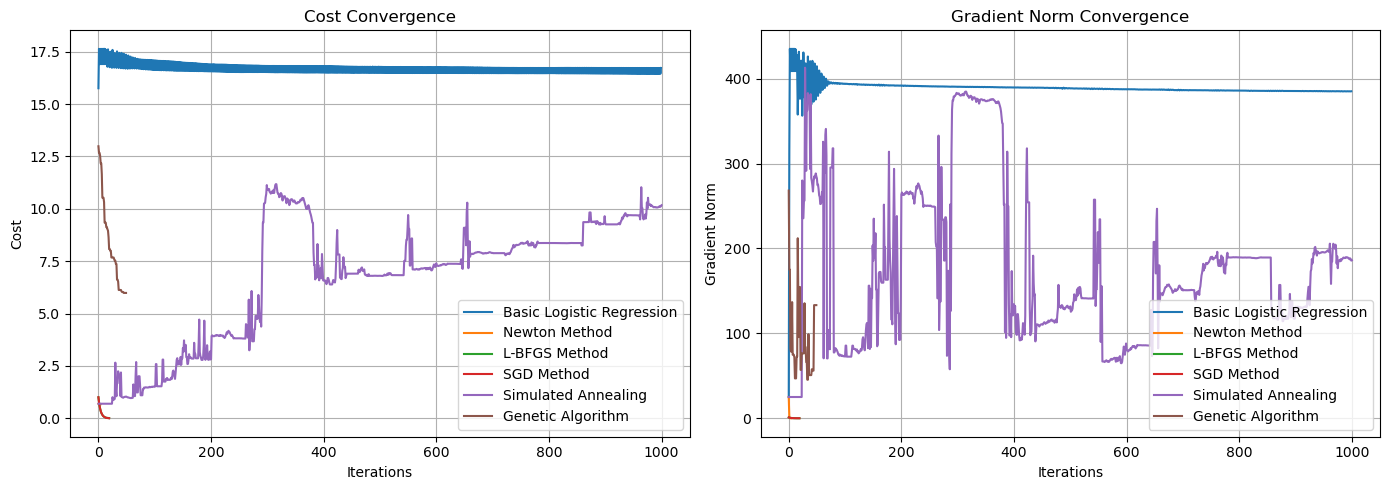

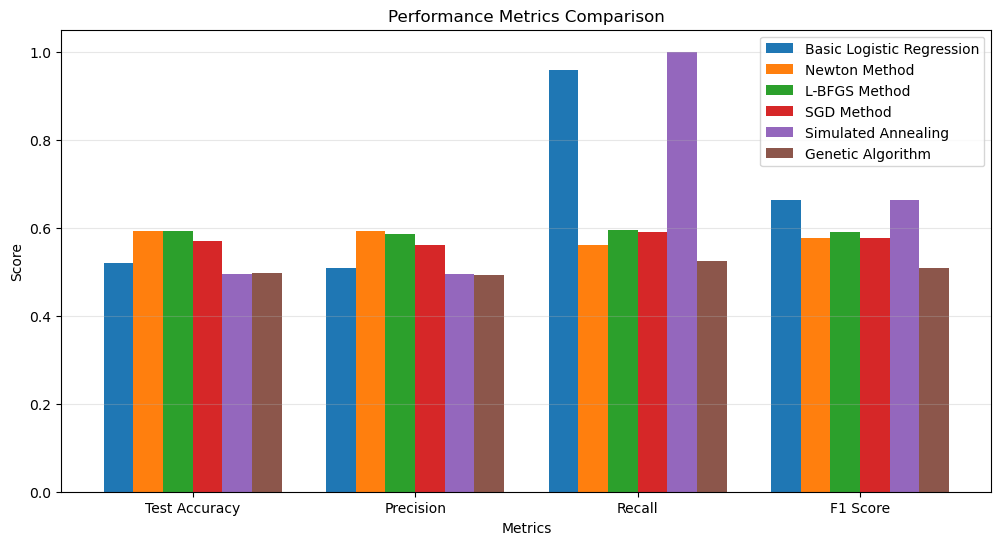

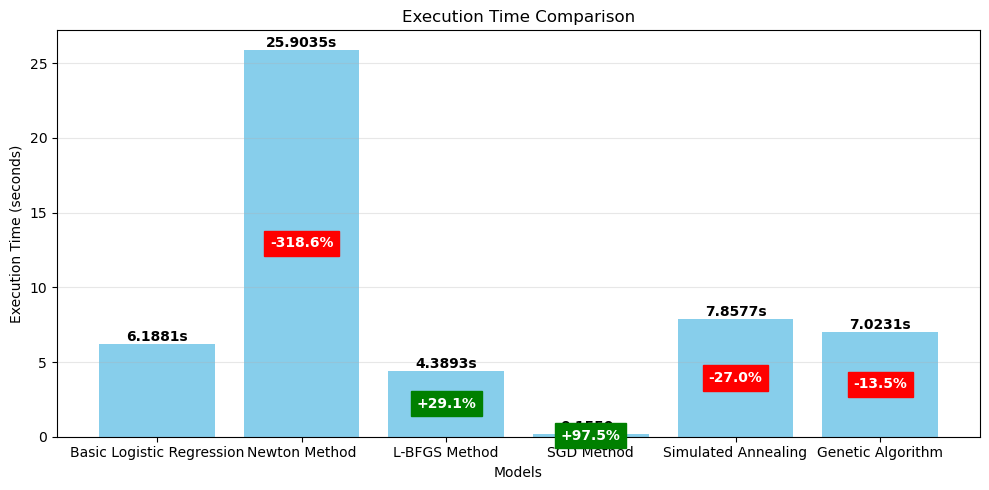

In [58]:
plot_convergence(model_results)
plot_performance_comparison(model_results)
plot_execution_times(model_results)

## Compare each algorithm

### Newton Method

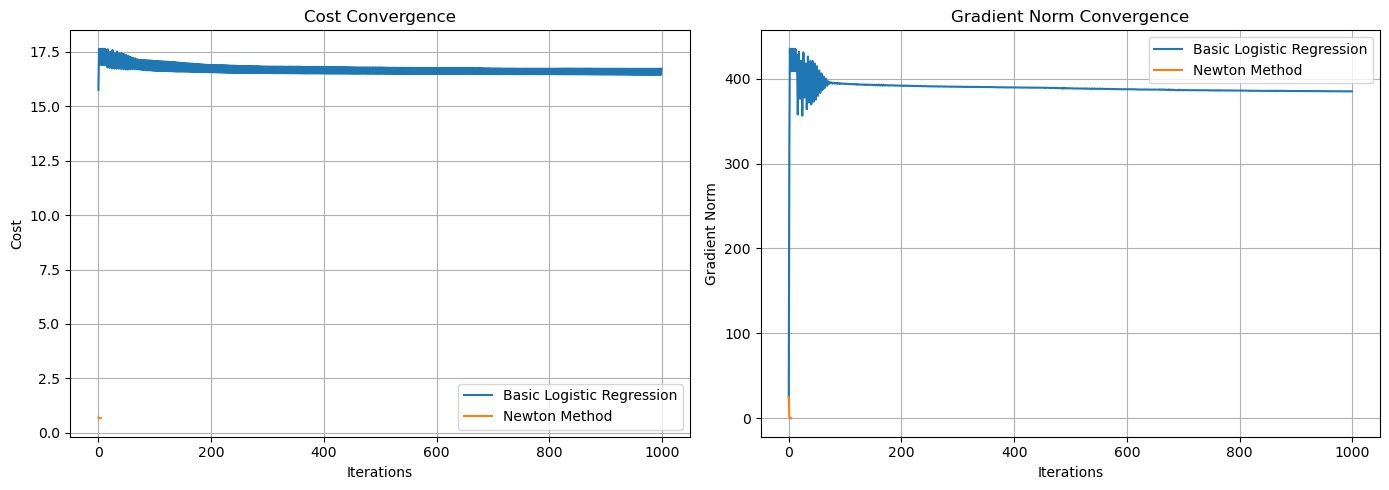

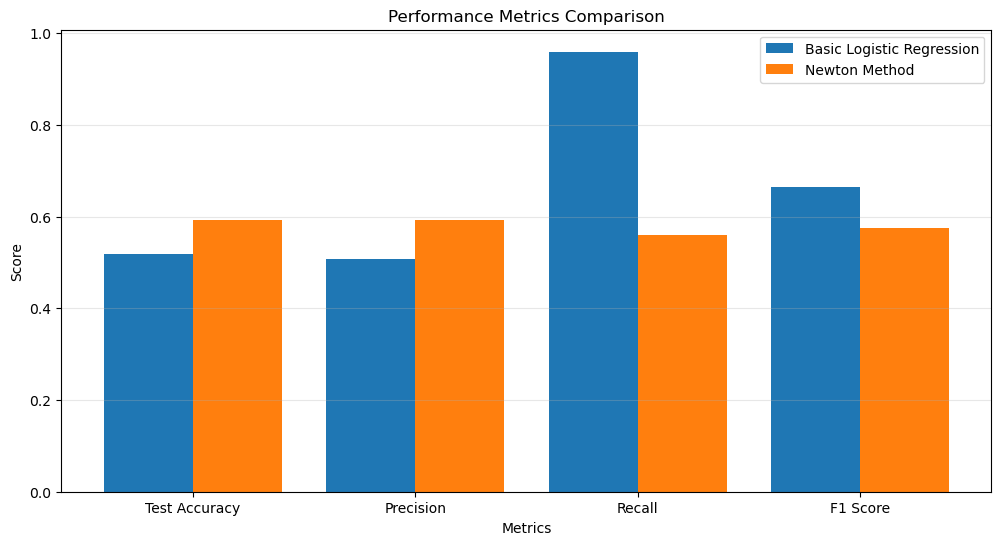

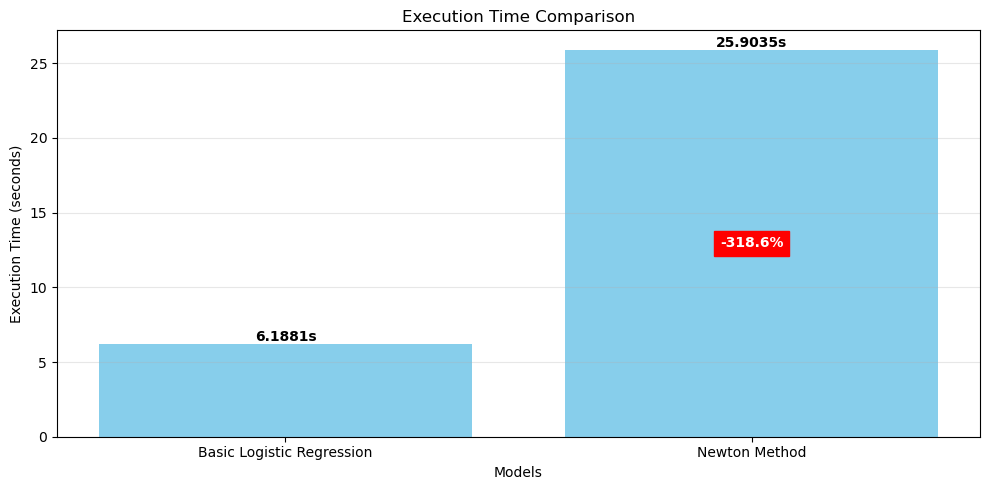

In [59]:
compare_algorithms(model_results, algorithms=['Newton Method'])

### L-BFGS

In [ ]:
compare_algorithms(model_results, algorithms=['L-BFGS Method'])

### SGD

In [ ]:
compare_algorithms(model_results, algorithms=['SGD Method'])

#### Parameter SGD

Starting parameter tuning for SGD Logistic Regression...

--- Tuning Learning Rate ---
Training Basic Logistic Regression...


C:\Users\HUAWE\AppData\Local\Temp\ipykernel_19896\2037776822.py:21: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))
C:\Users\HUAWE\AppData\Local\Temp\ipykernel_19896\2037776822.py:21: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))
C:\Users\HUAWE\AppData\Local\Temp\ipykernel_19896\2037776822.py:21: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))
C:\Users\HUAWE\AppData\Local\Temp\ipykernel_19896\2037776822.py:21: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))
C:\Users\HUAWE\AppData\Local\Temp\ipykernel_19896\2037776822.py:21: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))
C:\Users\HUAWE\AppData\Local\Temp\ipykernel_19896\2037776822.py:21: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))
C:\Users\HUAWE\AppData\Local\Temp\ipykernel_19896\2037776822.py:21: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))
C:\Use

C:\Users\HUAWE\AppData\Local\Temp\ipykernel_19896\2037776822.py:21: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))
C:\Users\HUAWE\AppData\Local\Temp\ipykernel_19896\2037776822.py:21: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))
C:\Users\HUAWE\AppData\Local\Temp\ipykernel_19896\2037776822.py:21: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))
C:\Users\HUAWE\AppData\Local\Temp\ipykernel_19896\2037776822.py:21: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))
C:\Users\HUAWE\AppData\Local\Temp\ipykernel_19896\2037776822.py:21: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))
C:\Users\HUAWE\AppData\Local\Temp\ipykernel_19896\2037776822.py:21: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))
C:\Users\HUAWE\AppData\Local\Temp\ipykernel_19896\2037776822.py:21: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))
C:\Use

C:\Users\HUAWE\AppData\Local\Temp\ipykernel_19896\2037776822.py:21: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))
C:\Users\HUAWE\AppData\Local\Temp\ipykernel_19896\2037776822.py:21: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))
C:\Users\HUAWE\AppData\Local\Temp\ipykernel_19896\2037776822.py:21: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))
C:\Users\HUAWE\AppData\Local\Temp\ipykernel_19896\2037776822.py:21: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))
C:\Users\HUAWE\AppData\Local\Temp\ipykernel_19896\2037776822.py:21: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))
C:\Users\HUAWE\AppData\Local\Temp\ipykernel_19896\2037776822.py:21: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))
C:\Users\HUAWE\AppData\Local\Temp\ipykernel_19896\2037776822.py:21: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))
C:\Use

C:\Users\HUAWE\AppData\Local\Temp\ipykernel_19896\2037776822.py:21: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))
C:\Users\HUAWE\AppData\Local\Temp\ipykernel_19896\2037776822.py:21: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))
C:\Users\HUAWE\AppData\Local\Temp\ipykernel_19896\2037776822.py:21: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))
C:\Users\HUAWE\AppData\Local\Temp\ipykernel_19896\2037776822.py:21: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))
C:\Users\HUAWE\AppData\Local\Temp\ipykernel_19896\2037776822.py:21: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))
C:\Users\HUAWE\AppData\Local\Temp\ipykernel_19896\2037776822.py:21: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))
C:\Users\HUAWE\AppData\Local\Temp\ipykernel_19896\2037776822.py:21: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))
C:\Use

...

C:\Users\HUAWE\AppData\Local\Temp\ipykernel_19896\2037776822.py:21: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))
C:\Users\HUAWE\AppData\Local\Temp\ipykernel_19896\2037776822.py:21: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))
C:\Users\HUAWE\AppData\Local\Temp\ipykernel_19896\2037776822.py:21: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))
C:\Users\HUAWE\AppData\Local\Temp\ipykernel_19896\2037776822.py:21: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))
C:\Users\HUAWE\AppData\Local\Temp\ipykernel_19896\2037776822.py:21: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))
C:\Users\HUAWE\AppData\Local\Temp\ipykernel_19896\2037776822.py:21: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))
C:\Users\HUAWE\AppData\Local\Temp\ipykernel_19896\2037776822.py:21: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))
C:\Use

C:\Users\HUAWE\AppData\Local\Temp\ipykernel_19896\2037776822.py:21: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))
C:\Users\HUAWE\AppData\Local\Temp\ipykernel_19896\2037776822.py:21: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))
C:\Users\HUAWE\AppData\Local\Temp\ipykernel_19896\2037776822.py:21: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))
C:\Users\HUAWE\AppData\Local\Temp\ipykernel_19896\2037776822.py:21: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))
C:\Users\HUAWE\AppData\Local\Temp\ipykernel_19896\2037776822.py:21: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))
C:\Users\HUAWE\AppData\Local\Temp\ipykernel_19896\2037776822.py:21: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))
C:\Users\HUAWE\AppData\Local\Temp\ipykernel_19896\2037776822.py:21: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))
C:\Use

C:\Users\HUAWE\AppData\Local\Temp\ipykernel_19896\2037776822.py:21: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))
C:\Users\HUAWE\AppData\Local\Temp\ipykernel_19896\2037776822.py:21: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))
C:\Users\HUAWE\AppData\Local\Temp\ipykernel_19896\2037776822.py:21: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))
C:\Users\HUAWE\AppData\Local\Temp\ipykernel_19896\2037776822.py:21: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))
C:\Users\HUAWE\AppData\Local\Temp\ipykernel_19896\2037776822.py:21: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))
C:\Users\HUAWE\AppData\Local\Temp\ipykernel_19896\2037776822.py:21: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))
C:\Users\HUAWE\AppData\Local\Temp\ipykernel_19896\2037776822.py:21: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))
C:\Use

C:\Users\HUAWE\AppData\Local\Temp\ipykernel_19896\2037776822.py:21: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))
C:\Users\HUAWE\AppData\Local\Temp\ipykernel_19896\2037776822.py:21: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))
C:\Users\HUAWE\AppData\Local\Temp\ipykernel_19896\2037776822.py:21: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))
C:\Users\HUAWE\AppData\Local\Temp\ipykernel_19896\2037776822.py:21: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))
C:\Users\HUAWE\AppData\Local\Temp\ipykernel_19896\2037776822.py:21: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))
C:\Users\HUAWE\AppData\Local\Temp\ipykernel_19896\2037776822.py:21: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))
C:\Users\HUAWE\AppData\Local\Temp\ipykernel_19896\2037776822.py:21: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))
C:\Use

Basic Logistic Regression: Test accuracy = 0.5195
Training SGDLogisticRegression (learning_rate=0.001)...
SGDLogisticRegression (learning_rate=0.001): Test accuracy = 0.5450
Training SGDLogisticRegression (learning_rate=0.01)...
SGDLogisticRegression (learning_rate=0.01): Test accuracy = 0.5693
Training SGDLogisticRegression (learning_rate=0.1)...
SGDLogisticRegression (learning_rate=0.1): Test accuracy = 0.5027


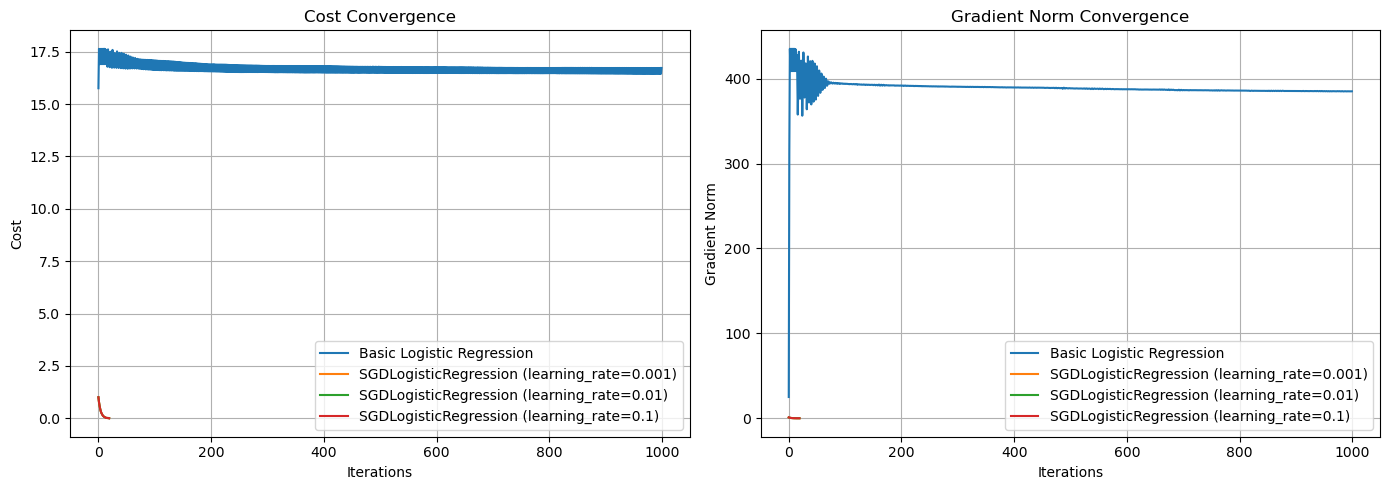

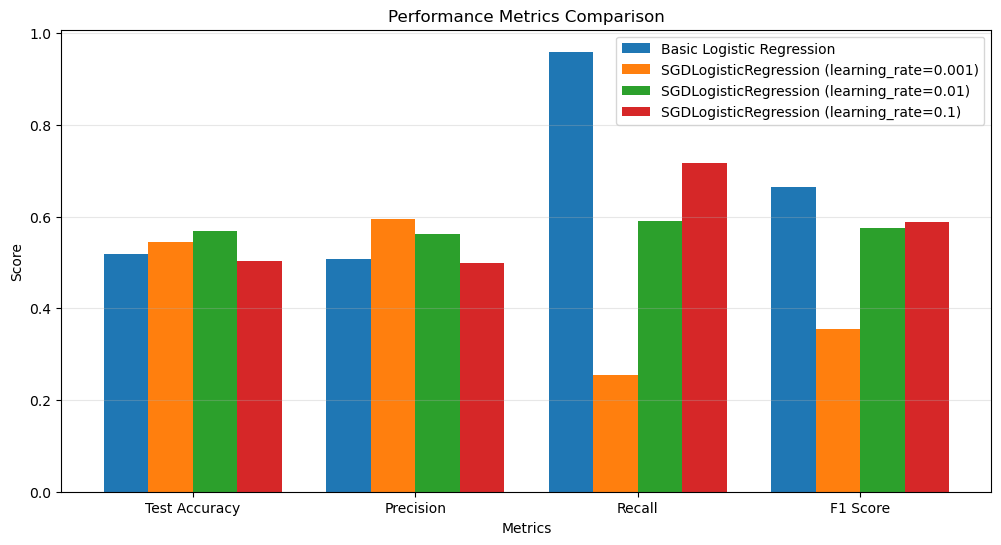

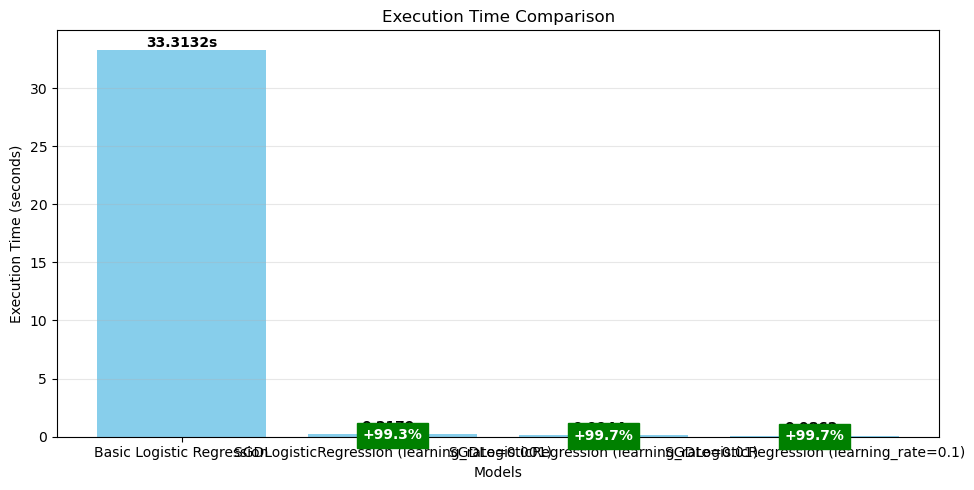

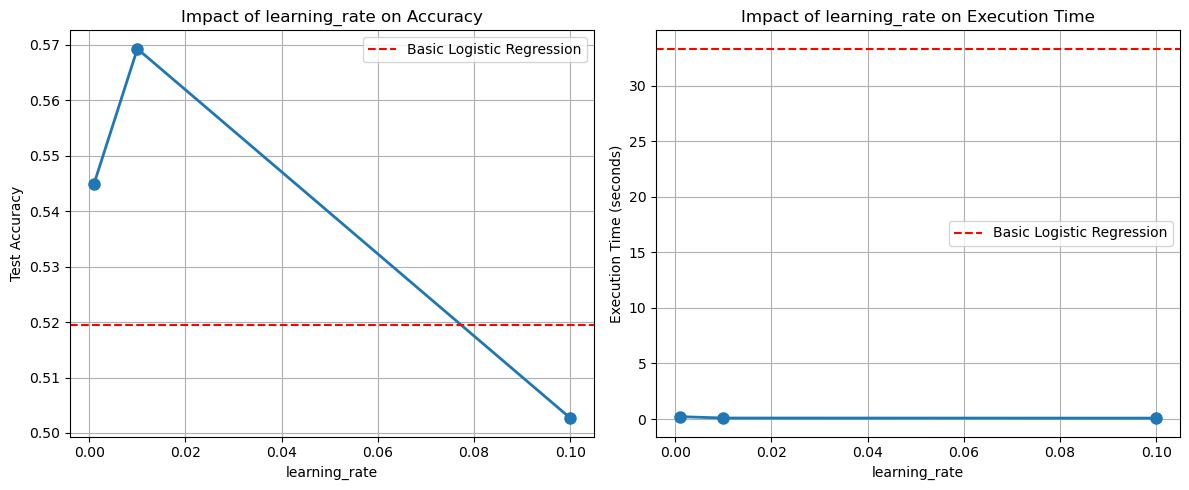

Best learning rate: 0.01 with test accuracy: 0.5693

--- Tuning Regularization Strength (Alpha) ---
Training SGDLogisticRegression (alpha=0.0001)...
SGDLogisticRegression (alpha=0.0001): Test accuracy = 0.5693
Training SGDLogisticRegression (alpha=0.001)...
SGDLogisticRegression (alpha=0.001): Test accuracy = 0.5062
Training SGDLogisticRegression (alpha=0.01)...
SGDLogisticRegression (alpha=0.01): Test accuracy = 0.5096


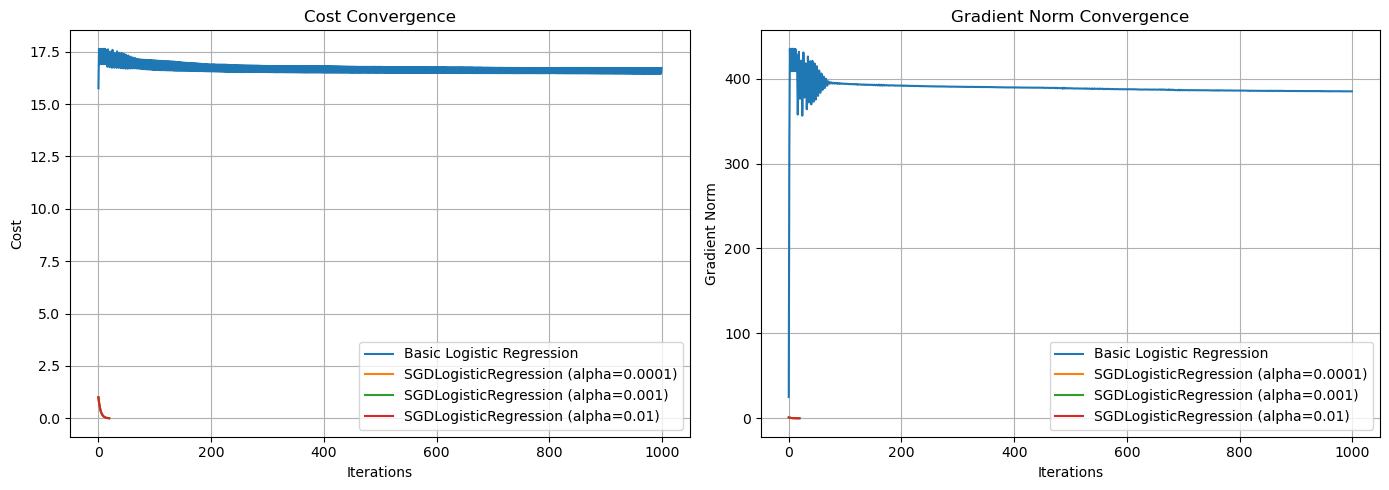

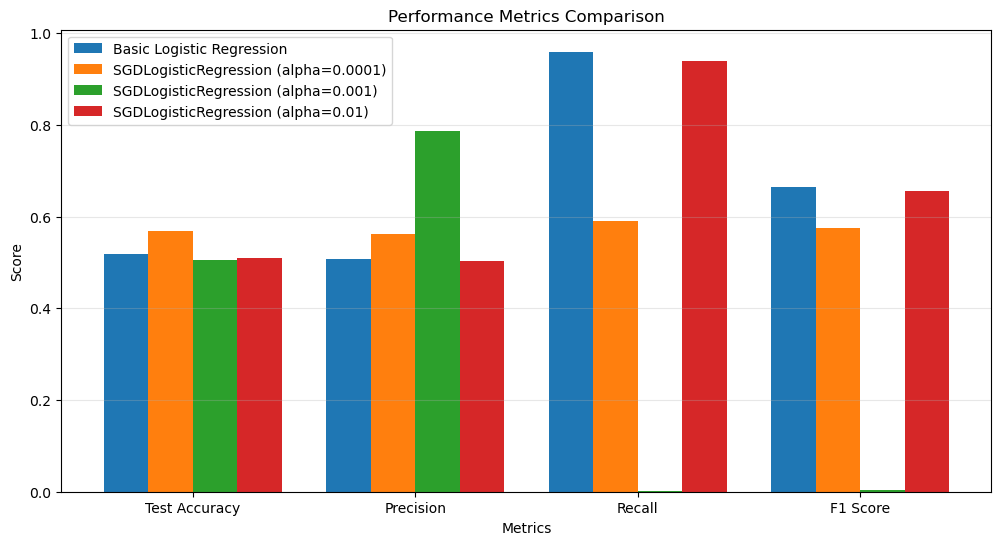

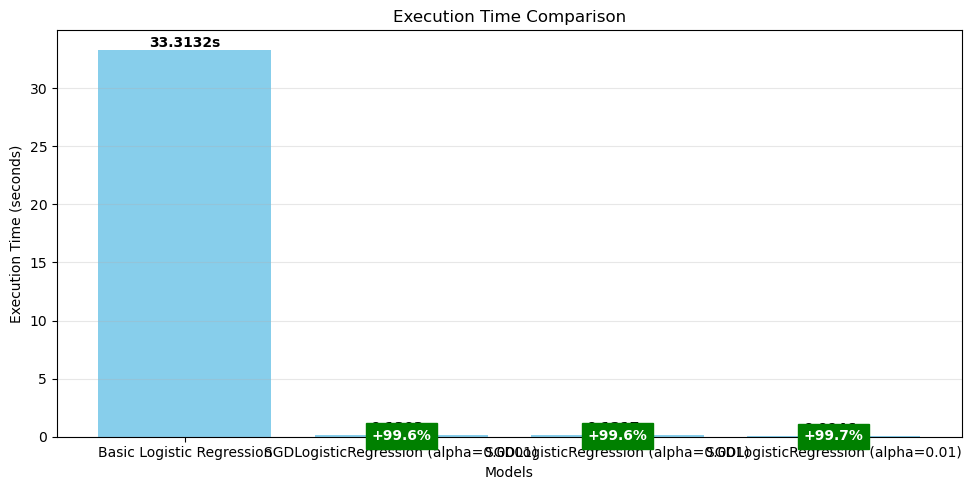

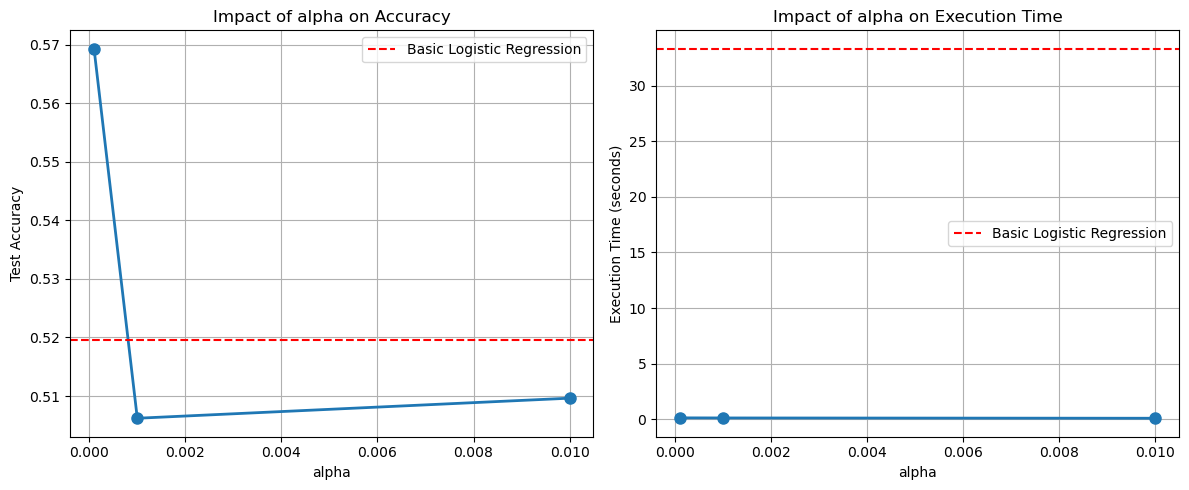

Best alpha: 0.0001 with test accuracy: 0.5693

--- Tuning Maximum Iterations ---
Training SGDLogisticRegression (max_iter=500)...
SGDLogisticRegression (max_iter=500): Test accuracy = 0.5693
Training SGDLogisticRegression (max_iter=1000)...
SGDLogisticRegression (max_iter=1000): Test accuracy = 0.5693
Training SGDLogisticRegression (max_iter=2000)...
SGDLogisticRegression (max_iter=2000): Test accuracy = 0.5693


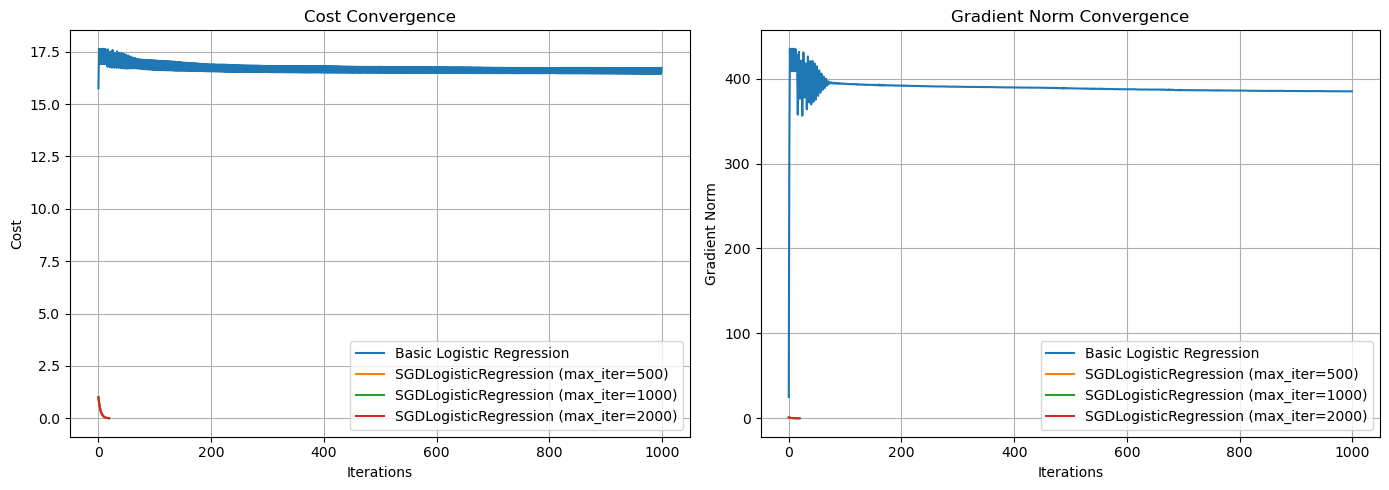

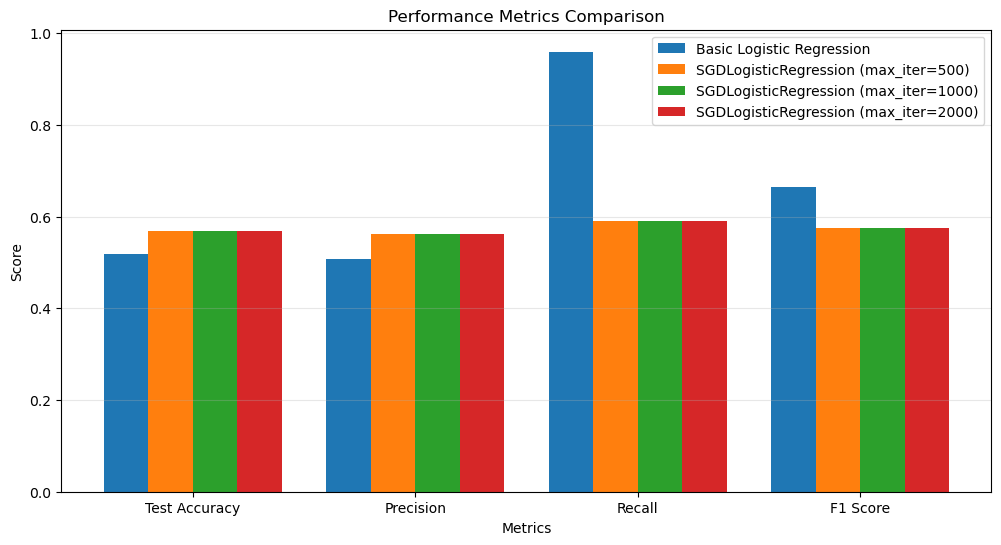

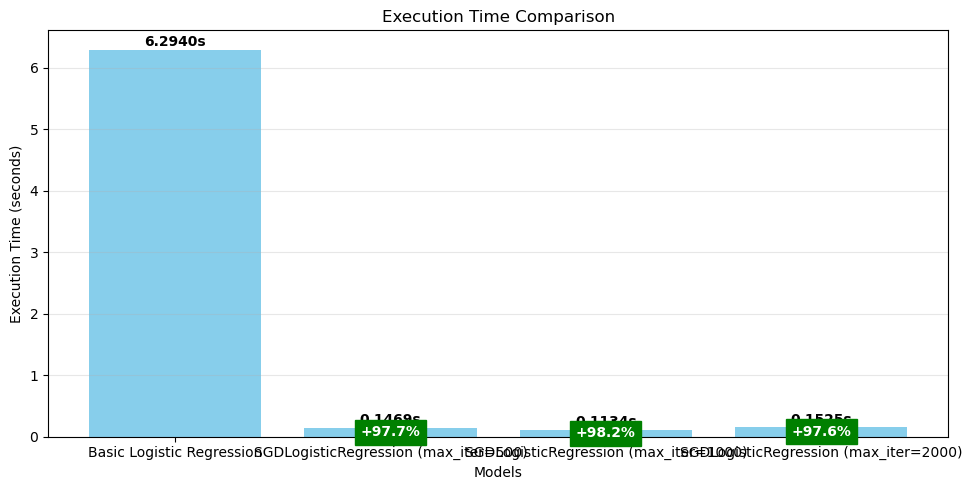

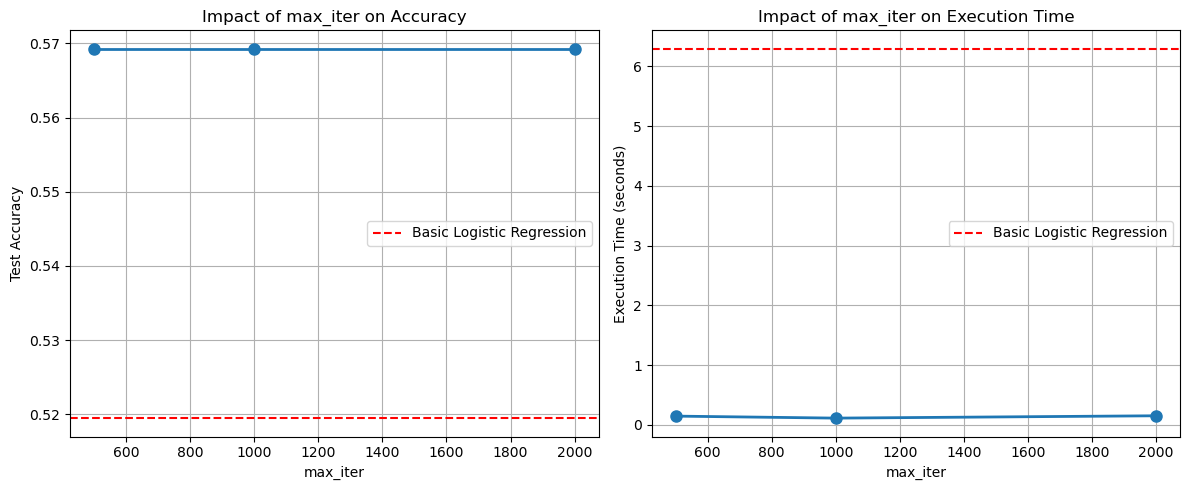

Best max_iter: 500 with test accuracy: 0.5693

--- Summary of Optimal Parameters ---
Optimal Learning Rate: 0.01
Optimal Regularization (Alpha): 0.0001
Optimal Maximum Iterations: 500

Training final SGD model with optimal parameters...
Final SGD Model completed in 0.1472 seconds
Test Accuracy: 0.5693
Test F1 Score: 0.5759
Test Precision: 0.5613
Test Recall: 0.5913


In [34]:
# 1. Parameter Grid Setup
print("Starting parameter tuning for SGD Logistic Regression...")
basic_model = LogisticRegression(max_iter=2000, solver='lbfgs')
# Define parameter ranges to explore
learning_rates = [0.001, 0.01, 0.1]
alphas = [0.0001, 0.001, 0.01] 
max_iters = [500, 1000, 2000]

# Base parameters
base_params = {
    'learning_rate': 0.01,
    'max_iter': 1000,
    'alpha': 0.0001,
    'tol': 1e-3,
    'random_state': 42
}

# 2. Tuning Learning Rate
print("\n--- Tuning Learning Rate ---")
lr_results = compare_parameter_variations(
    SGDLogisticRegression, 
    'learning_rate', 
    learning_rates, 
    X_train, X_test, y_train, y_test, 
    base_params=base_params
)

# Find the best learning rate
best_lr = None
best_lr_accuracy = 0
for name, result in lr_results.items():
    if 'learning_rate' in name and result['metrics']['test_accuracy'] > best_lr_accuracy:
        best_lr_accuracy = result['metrics']['test_accuracy']
        best_lr = float(name.split('=')[1].split(')')[0])

print(f"Best learning rate: {best_lr} with test accuracy: {best_lr_accuracy:.4f}")

# Update base parameters with best learning rate
base_params['learning_rate'] = best_lr

# 3. Tuning Regularization Strength (Alpha)
print("\n--- Tuning Regularization Strength (Alpha) ---")
alpha_results = compare_parameter_variations(
    SGDLogisticRegression, 
    'alpha', 
    alphas, 
    X_train, X_test, y_train, y_test, 
    base_params=base_params,
    basic_model=lr_results['Basic Logistic Regression']
)

# Find the best alpha
best_alpha = None
best_alpha_accuracy = 0
for name, result in alpha_results.items():
    if 'alpha' in name and result['metrics']['test_accuracy'] > best_alpha_accuracy:
        best_alpha_accuracy = result['metrics']['test_accuracy']
        best_alpha = float(name.split('=')[1].split(')')[0])

print(f"Best alpha: {best_alpha} with test accuracy: {best_alpha_accuracy:.4f}")

# Update base parameters with best alpha
base_params['alpha'] = best_alpha

# 4. Tuning Maximum Iterations
print("\n--- Tuning Maximum Iterations ---")
iter_results = compare_parameter_variations(
    SGDLogisticRegression, 
    'max_iter', 
    max_iters, 
    X_train, X_test, y_train, y_test, 
    base_params=base_params,
    basic_model=model_results['Basic Logistic Regression']
)

# Find the best max_iter
best_max_iter = None
best_max_iter_accuracy = 0
for name, result in iter_results.items():
    if 'max_iter' in name and result['metrics']['test_accuracy'] > best_max_iter_accuracy:
        best_max_iter_accuracy = result['metrics']['test_accuracy']
        best_max_iter = int(name.split('=')[1].split(')')[0])

print(f"Best max_iter: {best_max_iter} with test accuracy: {best_max_iter_accuracy:.4f}")

# 5. Final Optimized Parameters
print("\n--- Summary of Optimal Parameters ---")
print(f"Optimal Learning Rate: {best_lr}")
print(f"Optimal Regularization (Alpha): {best_alpha}")
print(f"Optimal Maximum Iterations: {best_max_iter}")

# 6. Train Final Model with Optimal Parameters
print("\nTraining final SGD model with optimal parameters...")
start_sgd = time.time()
final_sgd_model = SGDLogisticRegression(
    learning_rate=best_lr,
    max_iter=best_max_iter,
    alpha=best_alpha,
    tol=1e-3,
    random_state=42
)
final_sgd_model.fit(X_train, y_train)
sgd_time = time.time() - start_sgd

# 7. Evaluate Final Model
sgd_metrics = evaluate_model(final_sgd_model, X_train, X_test, y_train, y_test)
print(f"Final SGD Model completed in {sgd_time:.4f} seconds")
print(f"Test Accuracy: {sgd_metrics['test_accuracy']:.4f}")
print(f"Test F1 Score: {sgd_metrics['test_f1']:.4f}")
print(f"Test Precision: {sgd_metrics['test_precision']:.4f}")
print(f"Test Recall: {sgd_metrics['test_recall']:.4f}")

# 8. Visualize Final Results (comparing to basic model)
final_results = {
    'Basic Logistic Regression': lr_results['Basic Logistic Regression'],
    'Optimized SGD Logistic Regression': {
        'model': final_sgd_model,
        'costs': final_sgd_model.costs,
        'grad_norms': final_sgd_model.grad_norms,
        'metrics': sgd_metrics,
        'execution_time': sgd_time
    }
}


In [35]:
SGD_results = {
    'model': final_sgd_model,
    'costs': final_sgd_model.costs,
    'grad_norms': final_sgd_model.grad_norms,
    'metrics': sgd_metrics,
    'execution_time': sgd_time
}

### Simulated Annealing

In [ ]:
compare_algorithms(model_results, algorithms=['Simulated Annealing'])

### Parameter

In [21]:
print("Training Logistic Regression with Simulated Annealing...")
start_sa = time.time()
sa_model = LogisticRegressionSA(
    max_iterations=1000,
    initial_temp=1.0,
    cooling_rate=0.95,
    step_adjustments=20,
    cycles_per_temp=10,
    random_state=42
)
sa_model.fit(X_train.values, y_train.values)
sa_time = time.time() - start_sa
print(f"Simulated Annealing Method completed in {sa_time:.4f} seconds")

Training Logistic Regression with Simulated Annealing...
Simulated Annealing Method completed in 7.5936 seconds


In [22]:
sa_metrics = evaluate_model(sa_model, X_train.values, X_test.values, y_train.values, y_test.values)

# Save results for comparison
model_results['Simulated Annealing (tuned)'] = {
    'model': sa_model,
    'costs': sa_model.costs,
    'grad_norms': sa_model.grad_norms,
    'metrics': sa_metrics,
    'execution_time': sa_time
}

In [24]:
SAresult = {
    'Basic Logistic Regression':model_results['Basic Logistic Regression'],
    'Simulated Annealing (tuned)':model_results['Simulated Annealing (tuned)']
}


Visualizing convergence...


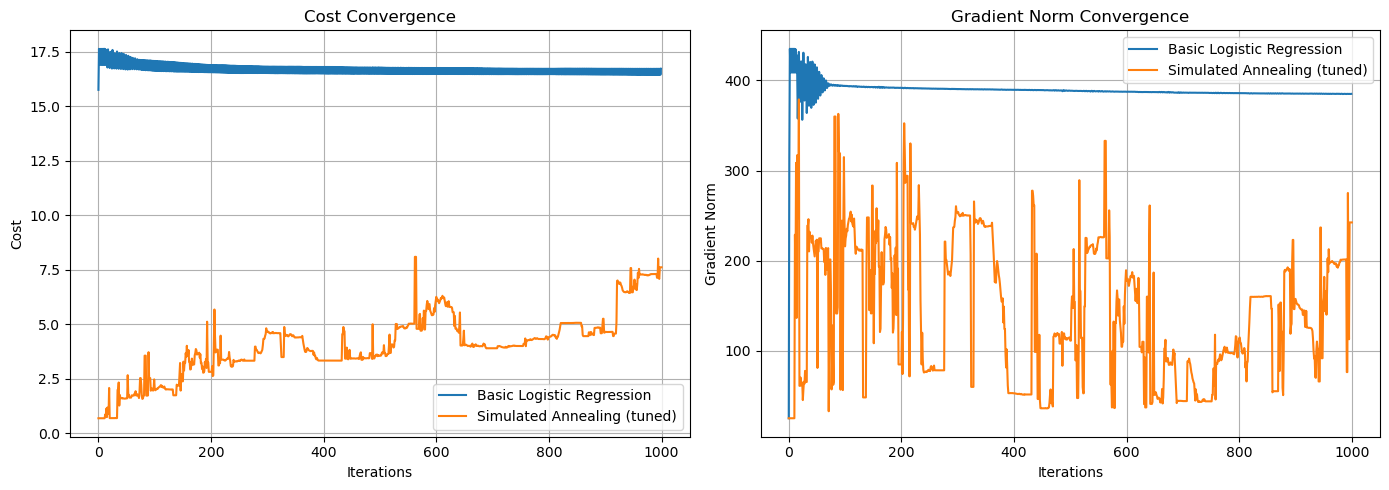


Visualizing performance comparison...


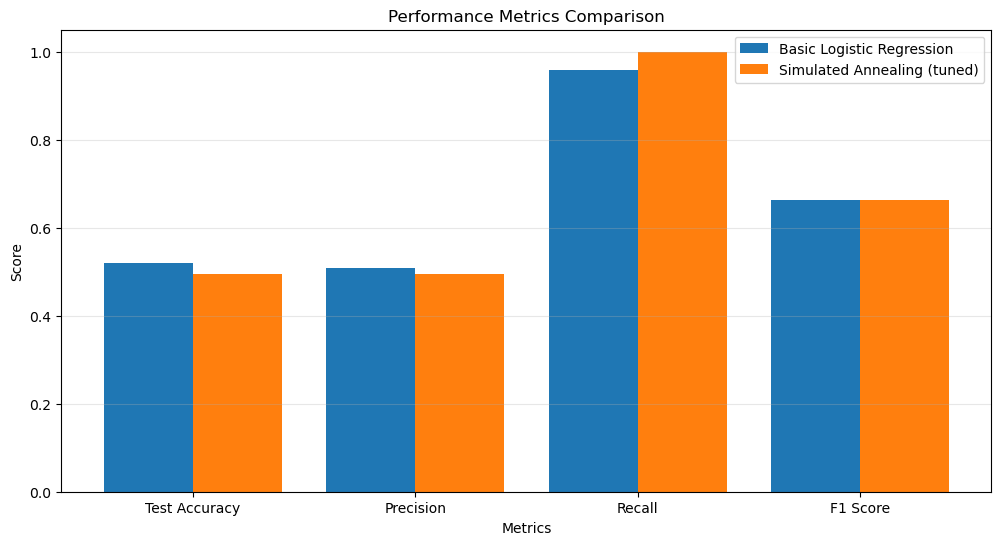


Visualizing execution times...


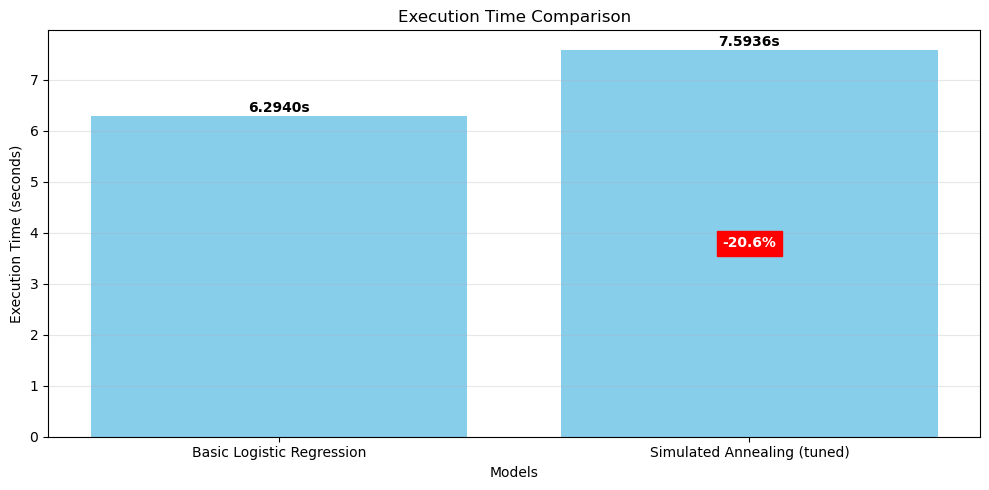

In [25]:
print("\nVisualizing convergence...")
plot_convergence(SAresult)

print("\nVisualizing performance comparison...")
plot_performance_comparison(SAresult)

print("\nVisualizing execution times...")
plot_execution_times(SAresult)

## Genetic Algorithm

In [ ]:
compare_algorithms(model_results, algorithms=['Genetic Algorithm'])


Comparing different population sizes for Genetic Algorithm...
Training GA (pop_size=10)...
Generation 0: Best Cost = 14.129966
Generation 10: Best Cost = 11.909620
Generation 19: Best Cost = 11.480875
GA (pop_size=10): Test accuracy = 0.5711
Training GA (pop_size=20)...
Generation 0: Best Cost = 12.983817
Generation 10: Best Cost = 11.571022
Generation 19: Best Cost = 10.360281
GA (pop_size=20): Test accuracy = 0.5303
Training GA (pop_size=50)...
Generation 0: Best Cost = 12.983817
Generation 10: Best Cost = 10.204261
Generation 19: Best Cost = 9.122291
GA (pop_size=50): Test accuracy = 0.5651


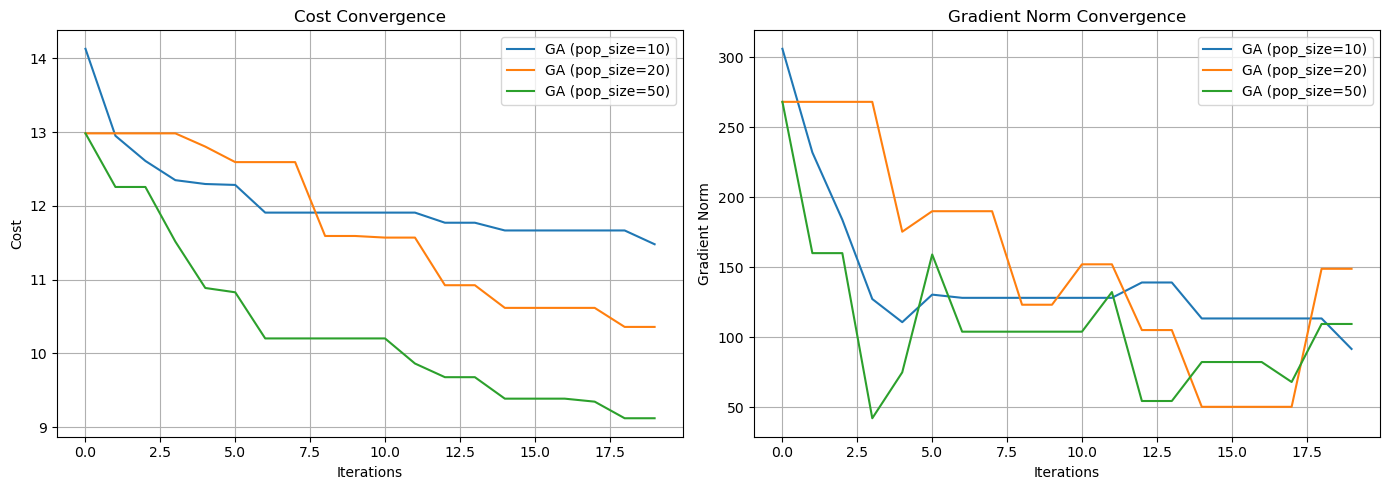

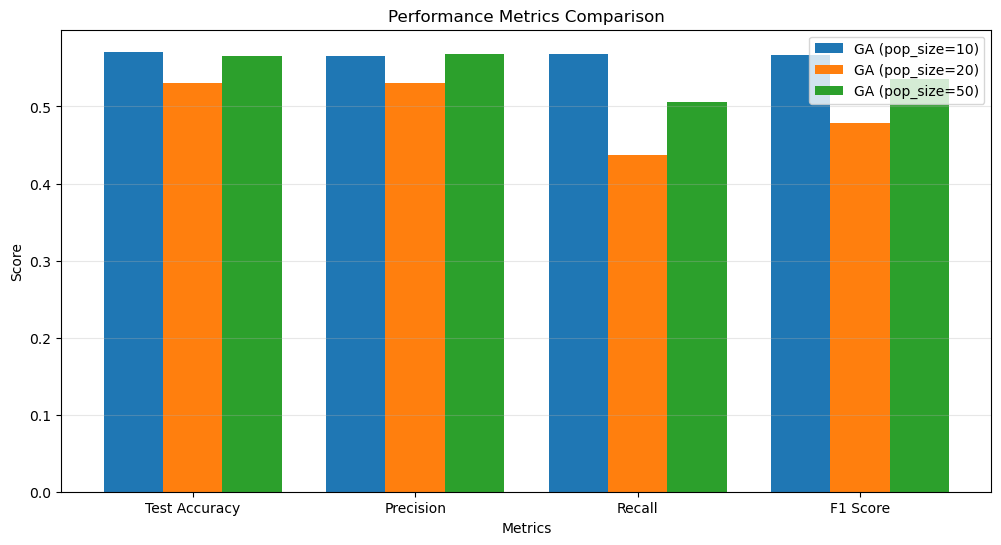

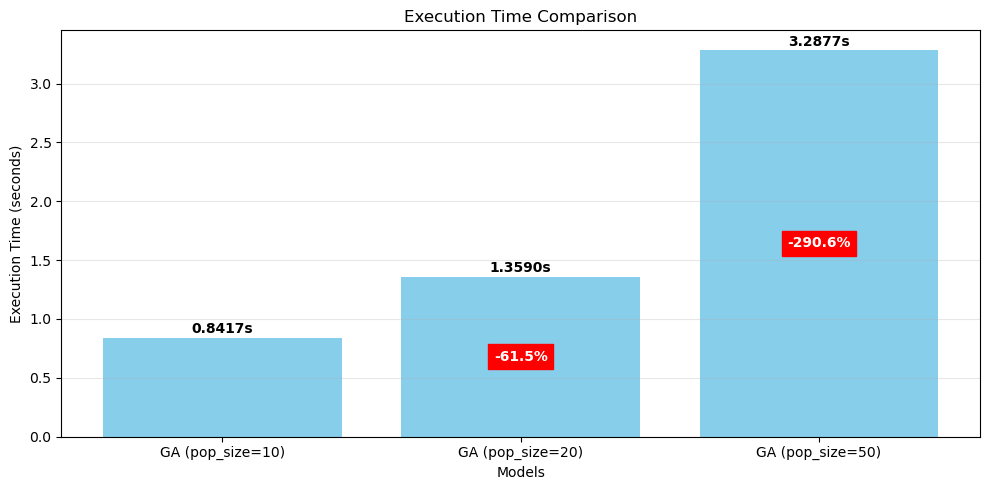


Comparing different mutation rates for Genetic Algorithm...
Training GA (mutation_rate=0.1)...
Generation 0: Best Cost = 12.983817
Generation 10: Best Cost = 11.343094
Generation 19: Best Cost = 10.700205
GA (mutation_rate=0.1): Test accuracy = 0.5725
Training GA (mutation_rate=0.2)...
Generation 0: Best Cost = 12.983817
Generation 10: Best Cost = 11.571022
Generation 19: Best Cost = 10.360281
GA (mutation_rate=0.2): Test accuracy = 0.5303
Training GA (mutation_rate=0.3)...
Generation 0: Best Cost = 12.983817
Generation 10: Best Cost = 10.754098
Generation 19: Best Cost = 10.754098
GA (mutation_rate=0.3): Test accuracy = 0.5707


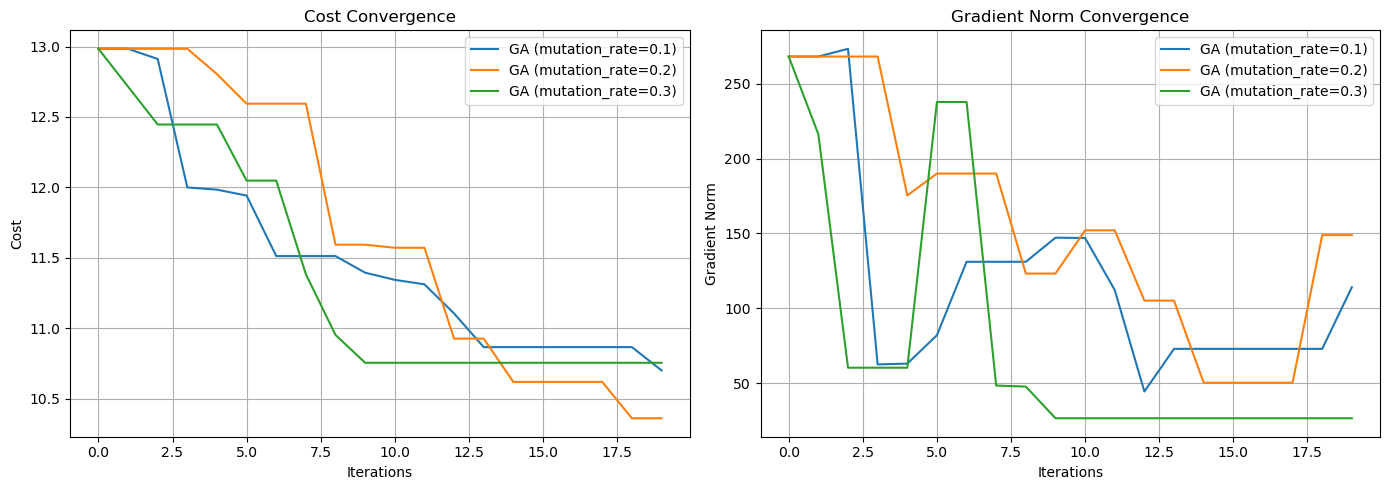

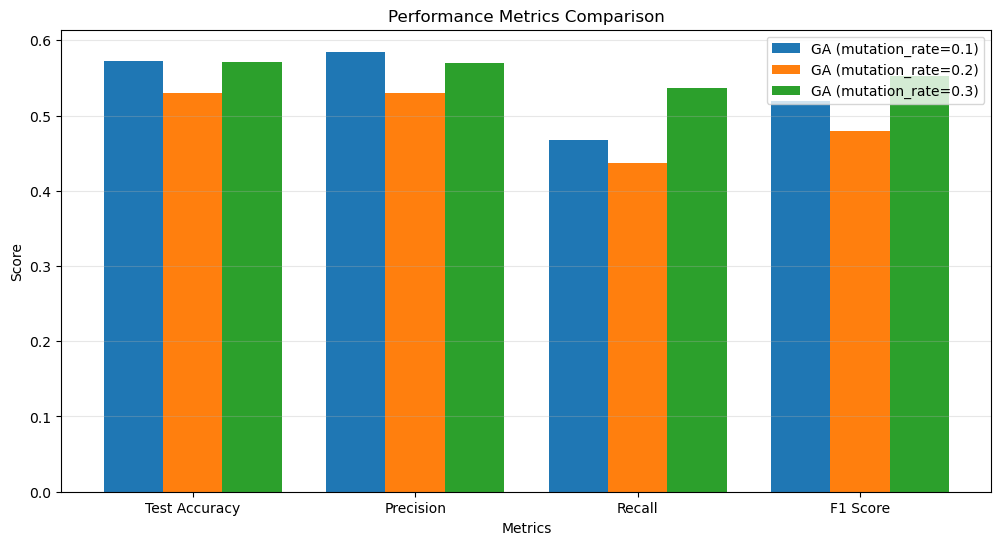

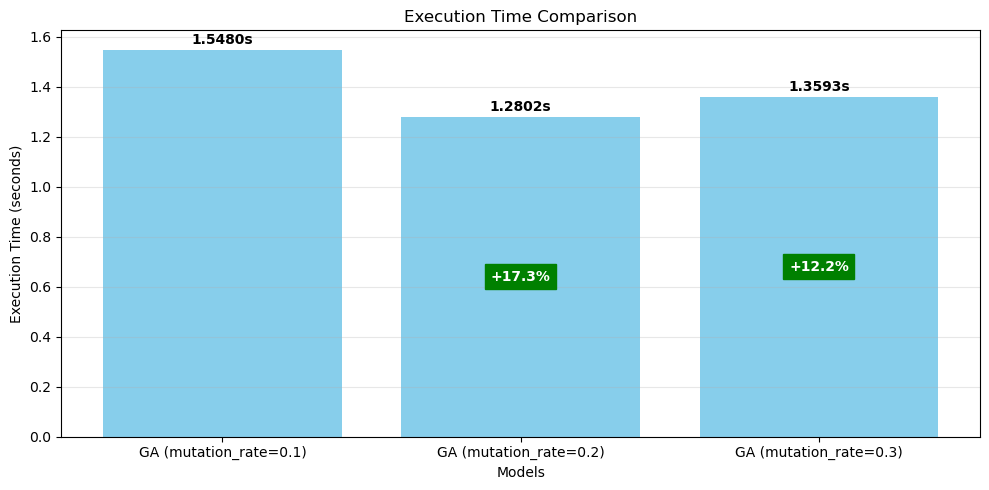

In [26]:
# Compare different population sizes
print("\nComparing different population sizes for Genetic Algorithm...")
population_sizes = [10, 20, 50]
ga_params = {
    'generations': 20,
    'mutation_rate': 0.2,
    'crossover_rate': 0.8,
    'elite_size': 2,
    'random_state': 42
}

# Store results for different population sizes
population_results = {}

for pop_size in population_sizes:
    model_name = f"GA (pop_size={pop_size})"
    print(f"Training {model_name}...")
    
    start_time = time.time()
    ga_model = GeneticAlgorithmLogisticRegression(
        population_size=pop_size,
        **ga_params
    )
    ga_model.fit(X_train.values, y_train.values)
    training_time = time.time() - start_time
    
    metrics = evaluate_model(ga_model, X_train.values, X_test.values, y_train.values, y_test.values)
    
    population_results[model_name] = {
        'model': ga_model,
        'costs': ga_model.costs,
        'grad_norms': ga_model.grad_norms,
        'metrics': metrics,
        'execution_time': training_time
    }
    print(f"{model_name}: Test accuracy = {metrics['test_accuracy']:.4f}")

# Visualize population size comparison
plot_convergence(population_results)
plot_performance_comparison(population_results)
plot_execution_times(population_results)

# Compare different mutation rates
print("\nComparing different mutation rates for Genetic Algorithm...")
mutation_rates = [0.1, 0.2, 0.3]
ga_params = {
    'population_size': 20,
    'generations': 20,
    'crossover_rate': 0.8,
    'elite_size': 2,
    'random_state': 42
}

# Store results for different mutation rates
mutation_results = {}

for mut_rate in mutation_rates:
    model_name = f"GA (mutation_rate={mut_rate})"
    print(f"Training {model_name}...")
    
    start_time = time.time()
    ga_model = GeneticAlgorithmLogisticRegression(
        mutation_rate=mut_rate,
        **ga_params
    )
    ga_model.fit(X_train.values, y_train.values)
    training_time = time.time() - start_time
    
    metrics = evaluate_model(ga_model, X_train.values, X_test.values, y_train.values, y_test.values)
    
    mutation_results[model_name] = {
        'model': ga_model,
        'costs': ga_model.costs,
        'grad_norms': ga_model.grad_norms,
        'metrics': metrics,
        'execution_time': training_time
    }
    print(f"{model_name}: Test accuracy = {metrics['test_accuracy']:.4f}")

# Visualize mutation rate comparison
plot_convergence(mutation_results)
plot_performance_comparison(mutation_results)
plot_execution_times(mutation_results)

In [27]:
# Train Genetic Algorithm with tuned parameters (pop_size=10, mutation_rate=0.3)
print("Training Genetic Algorithm with tuned parameters (pop_size=10, mutation_rate=0.3)...")
start_ga_tuned = time.time()
ga_model_tuned = GeneticAlgorithmLogisticRegression(
    population_size=10,
    generations=20,
    mutation_rate=0.3,
    crossover_rate=0.8,
    elite_size=2,
    random_state=42
)
ga_model_tuned.fit(X_train.values, y_train.values)
ga_tuned_time = time.time() - start_ga_tuned

# Evaluate tuned GA model
ga_tuned_metrics = evaluate_model(ga_model_tuned, X_train.values, X_test.values, y_train.values, y_test.values)
print(f"Genetic Algorithm (tuned): Test accuracy = {ga_tuned_metrics['test_accuracy']:.4f}")

# Save results for comparison
model_results['Genetic Algorithm (tuned)'] = {
    'model': ga_model_tuned,
    'costs': ga_model_tuned.costs,
    'grad_norms': ga_model_tuned.grad_norms,
    'metrics': ga_tuned_metrics,
    'execution_time': ga_tuned_time
}

Training Genetic Algorithm with tuned parameters (pop_size=10, mutation_rate=0.3)...
Generation 0: Best Cost = 14.129966
Generation 10: Best Cost = 10.887059
Generation 19: Best Cost = 10.542138
Genetic Algorithm (tuned): Test accuracy = 0.5537


In [31]:
GEresult = {
    'Basic Logistic Regression':model_results['Basic Logistic Regression'],
    'Genetic Method (tuned)':model_results['Genetic Algorithm (tuned)']
}


Visualizing convergence...


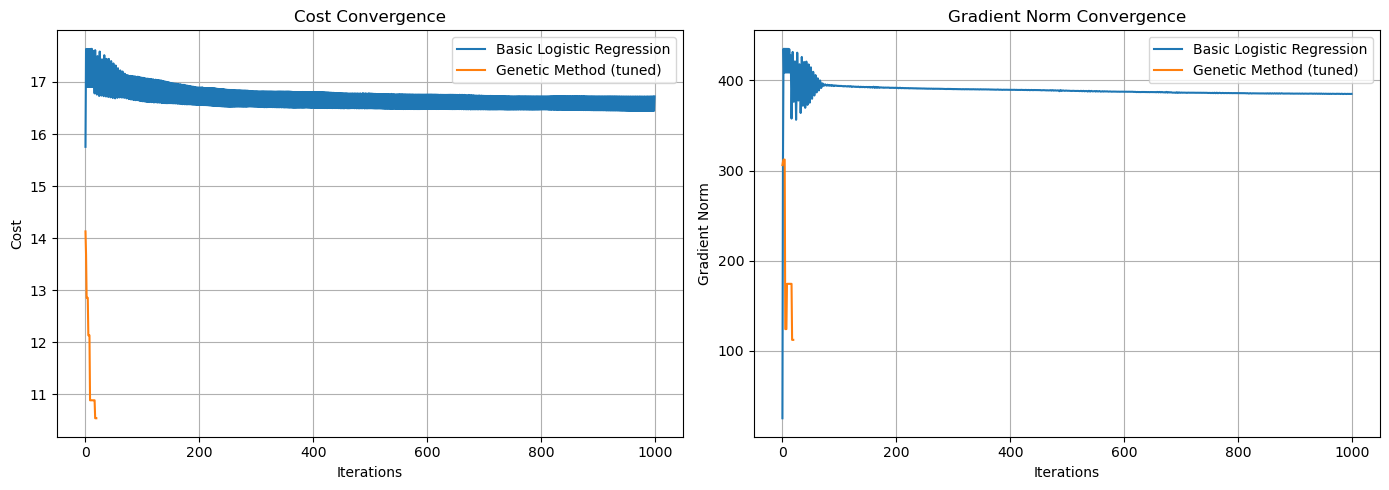


Visualizing performance comparison...


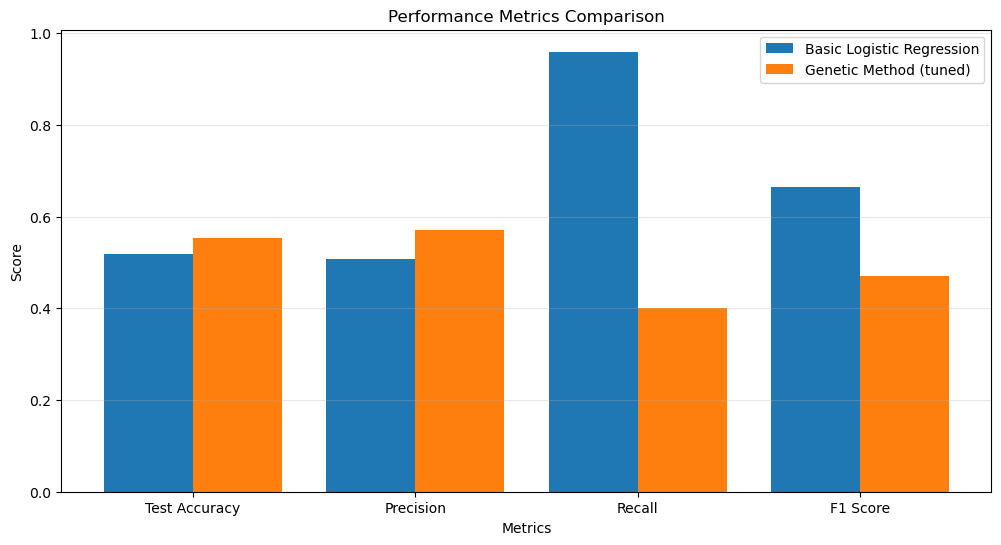


Visualizing execution times...


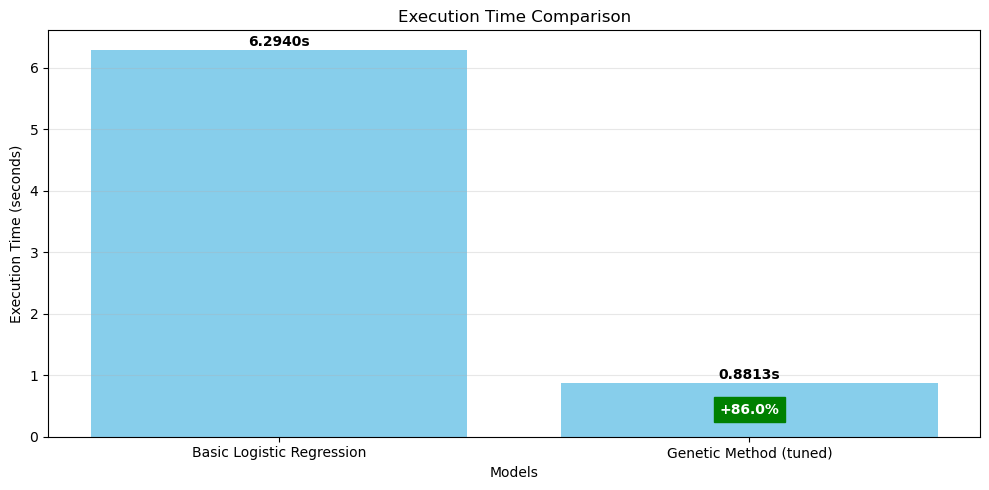

In [32]:
print("\nVisualizing convergence...")
plot_convergence(GEresult)

print("\nVisualizing performance comparison...")
plot_performance_comparison(GEresult)

print("\nVisualizing execution times...")
plot_execution_times(GEresult)

## Compare all Algorithms

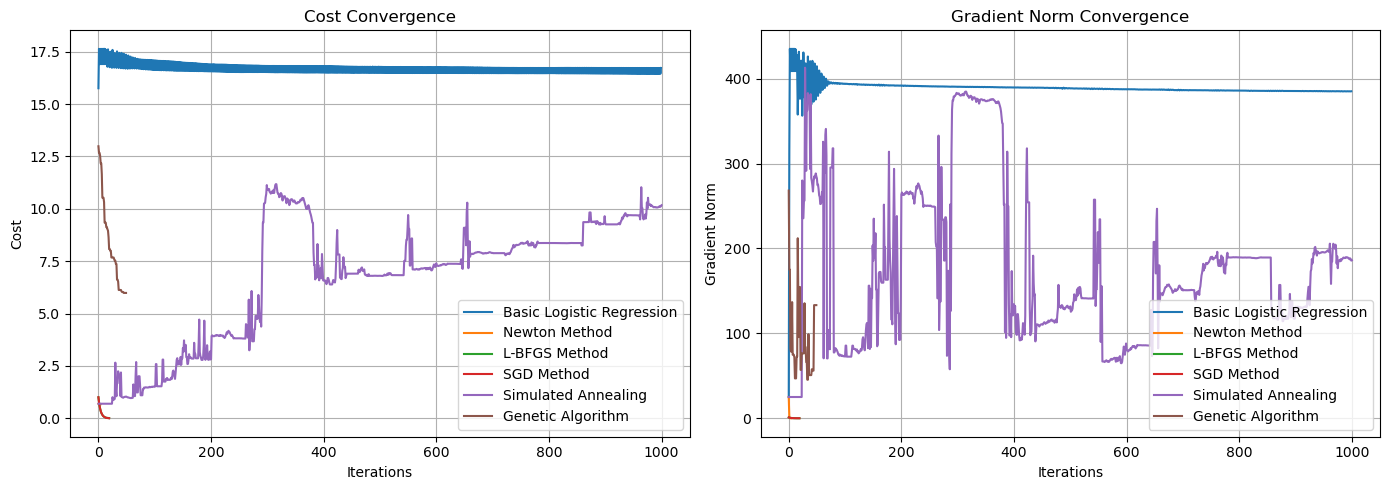

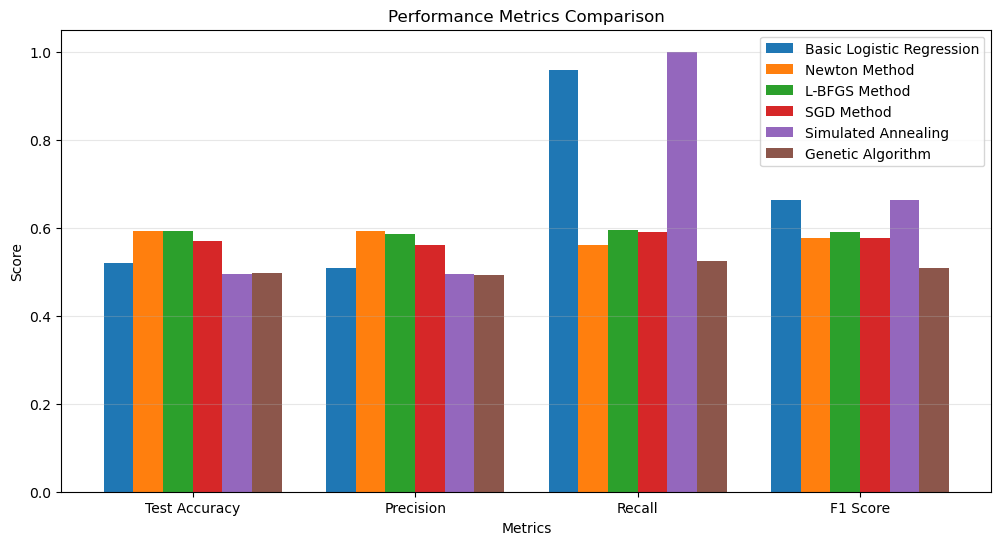

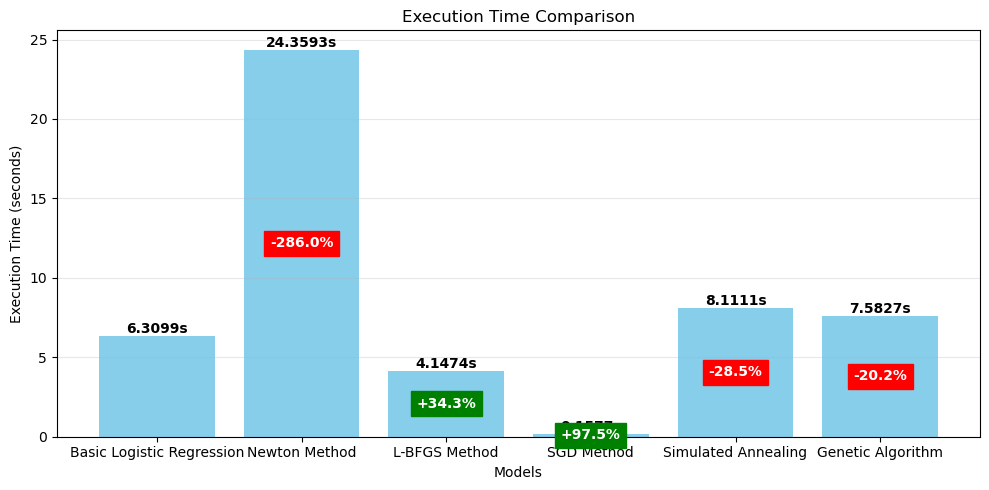

In [38]:
compare_algorithms(model_results, algorithms=['Newton Method','L-BFGS Method','SGD Method','Simulated Annealing','Genetic Algorithm'])

In [64]:
tuningresults = {
    'Basic Logistic Regression': model_results['Basic Logistic Regression'],
    'Newton Method(best)': model_results['Newton Method'],
    'L-BFGS Method (best)': model_results['L-BFGS Method'],
    'SGD Method (tuned)': SGD_results,
    'Simulated Annealing (tuned)': model_results['Simulated Annealing (tuned)'],
    'Genetic Method': model_results['Genetic Algorithm']
    
}


Visualizing convergence...


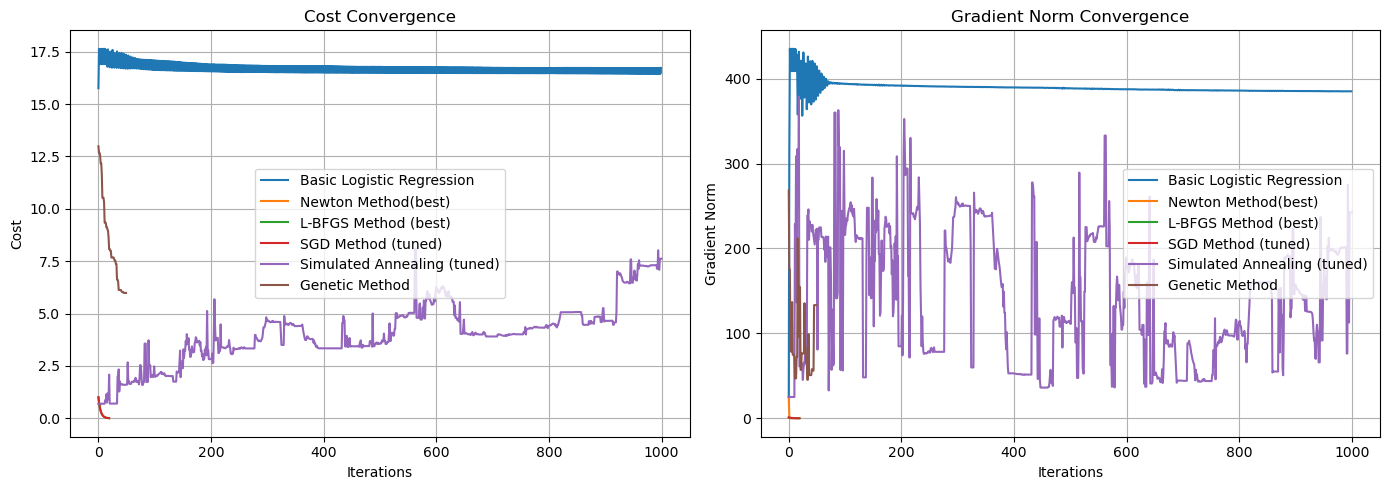


Visualizing performance comparison...


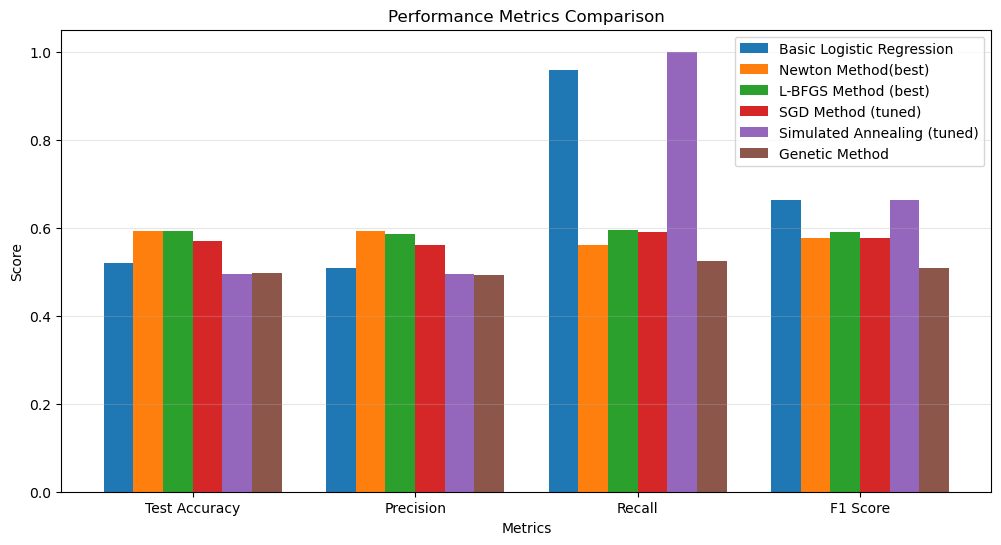


Visualizing execution times...


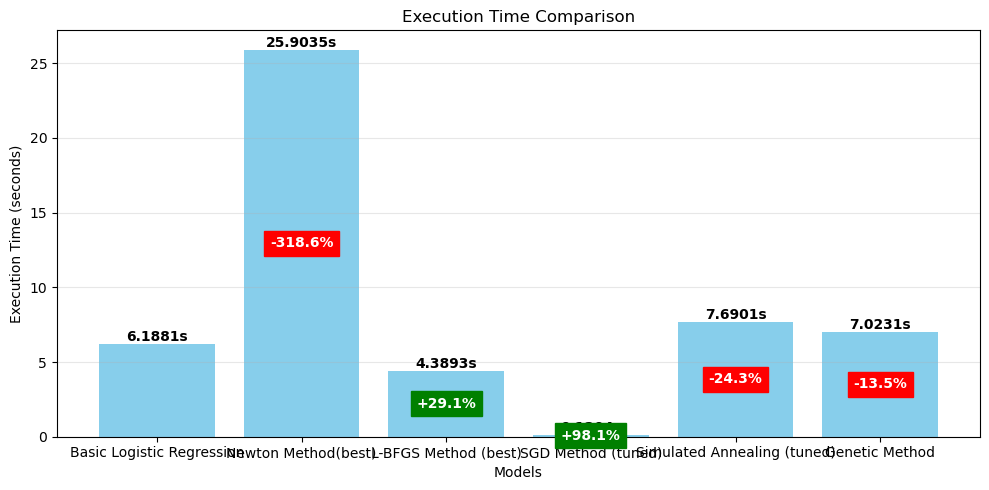

In [65]:
print("\nVisualizing convergence...")
plot_convergence(tuningresults)

print("\nVisualizing performance comparison...")
plot_performance_comparison(tuningresults)

print("\nVisualizing execution times...")
plot_execution_times(tuningresults)

In [38]:
NEWtuningresults = {
    'Basic Logistic Regression': model_results['Basic Logistic Regression'],
    'Newton Method': model_results['Newton Method'],
    'L-BFGS Method': model_results['L-BFGS Method'],
    'SGD Method': SGD_results,
    'Simulated Annealing': model_results['Simulated Annealing (tuned)'],
    'Genetic Method': model_results['Genetic Algorithm (tuned)']
    
}


Visualizing convergence...


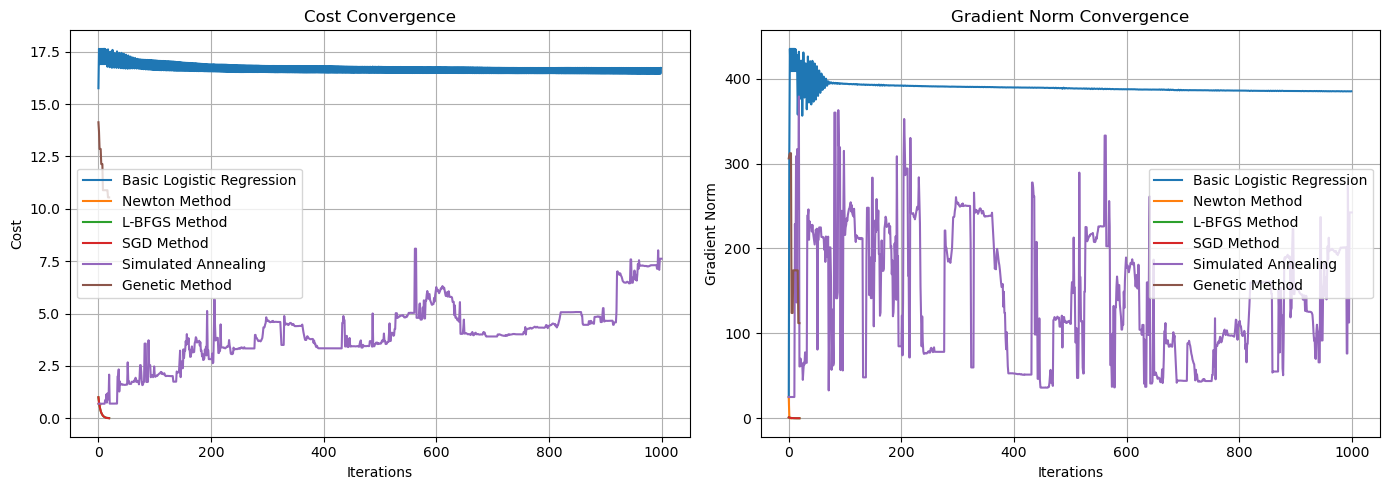


Visualizing performance comparison...


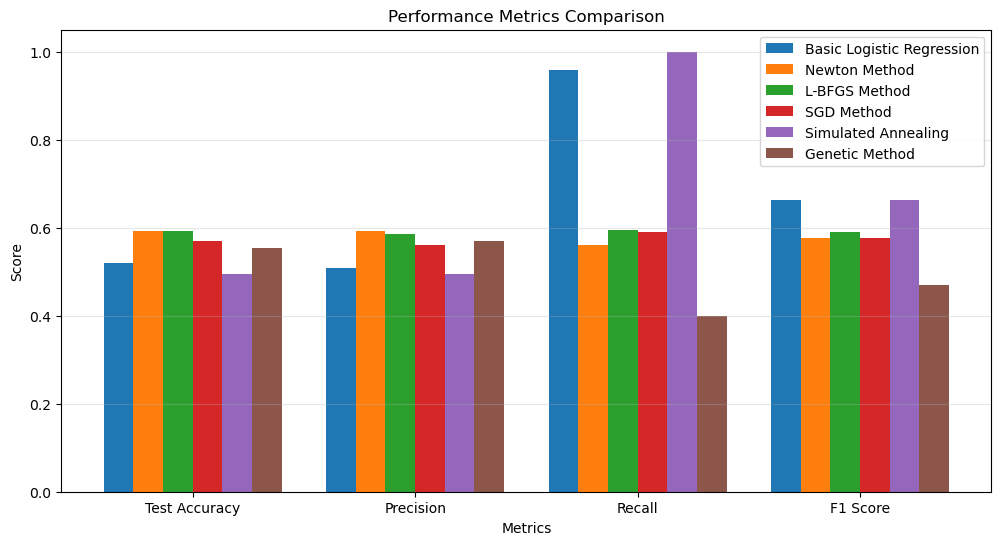


Visualizing execution times...


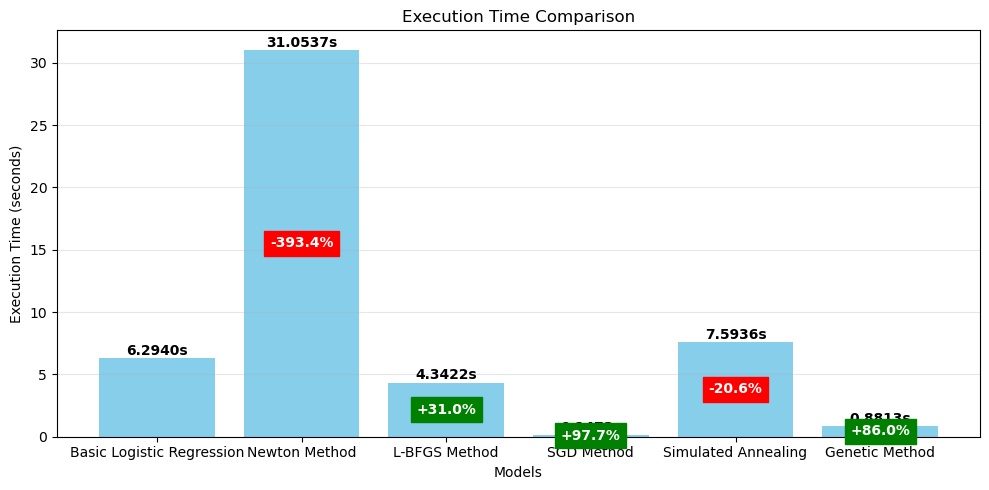

In [39]:
print("\nVisualizing convergence...")
plot_convergence(NEWtuningresults)

print("\nVisualizing performance comparison...")
plot_performance_comparison(NEWtuningresults)

print("\nVisualizing execution times...")
plot_execution_times(NEWtuningresults)

In [41]:
import os

Saved convergence plot to plots/convergence.png


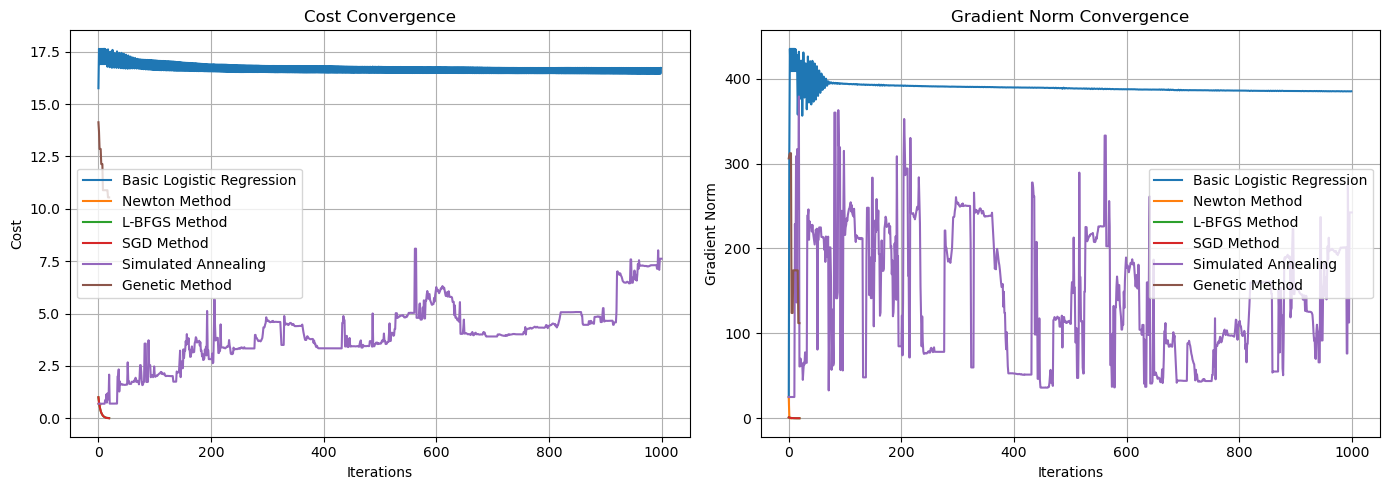

Saved performance comparison plot to plots/performance_comparison.png


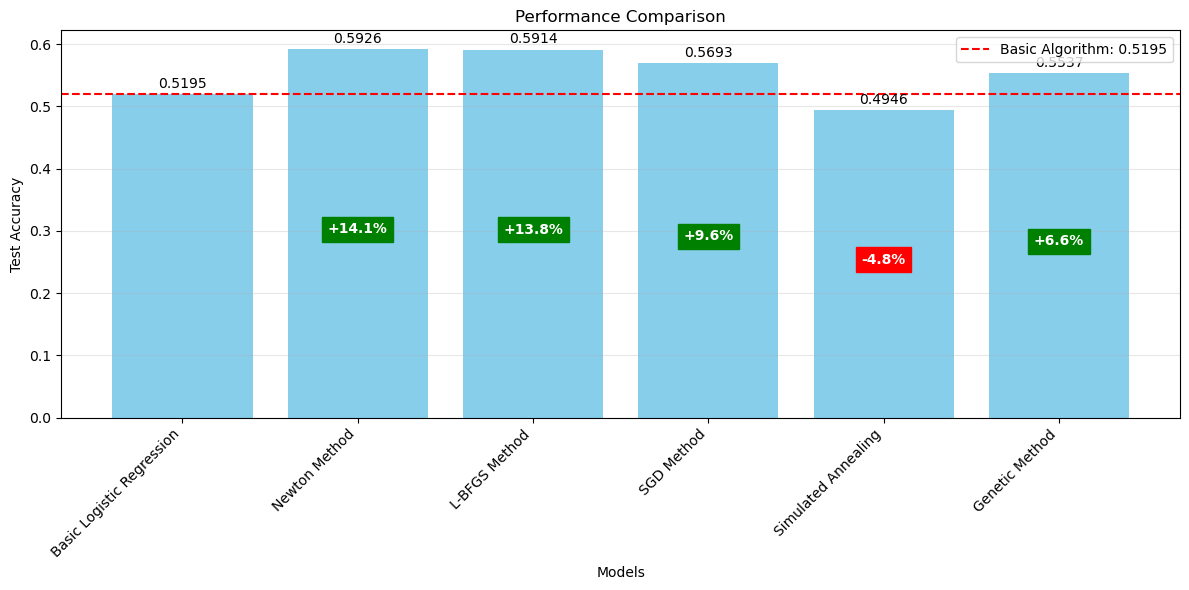

Saved execution time plot to plots/execution_times.png


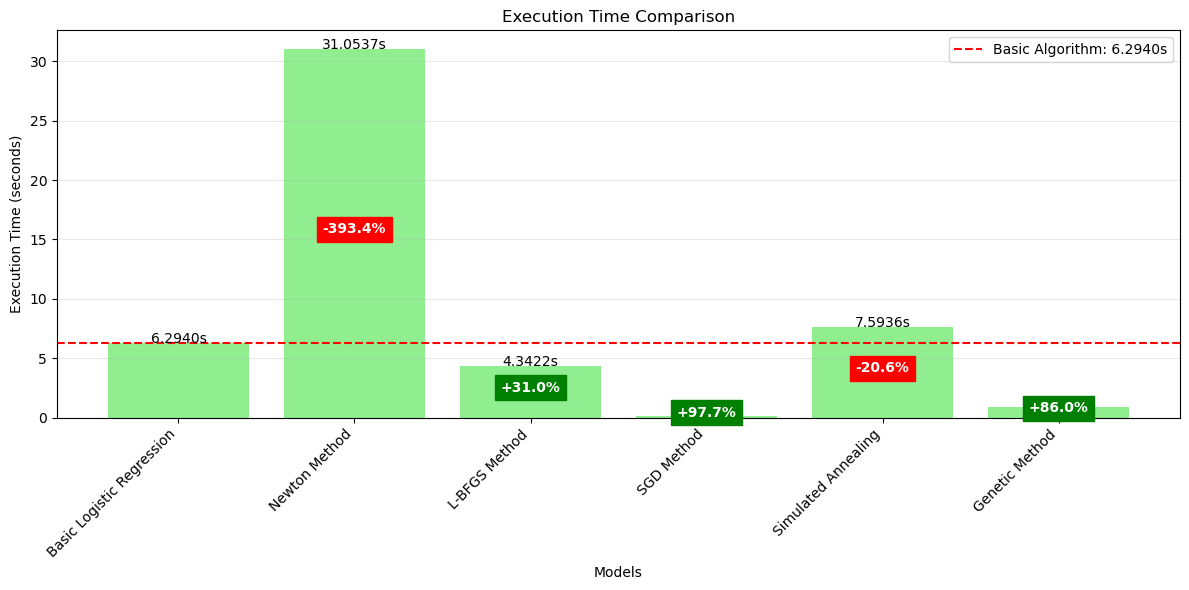

True

In [42]:
# First, ensure the plots directory exists
if not os.path.exists("plots"):
    os.makedirs("plots")
    print("Created plots directory")

# Define functions to recreate each plot from scratch using your data

def recreate_and_save_convergence(tuningresults, save_path="plots/convergence.png"):
    """Recreate the convergence plot from data and save it"""
    plt.figure(figsize=(14, 5))
    
    # Plot cost convergence
    plt.subplot(1, 2, 1)
    for name, result in tuningresults.items():
        if 'costs' in result:
            plt.plot(result['costs'], label=name)
        else:
            print(f"Warning: 'costs' missing for {name}")
    
    plt.title('Cost Convergence')
    plt.xlabel('Iterations')
    plt.ylabel('Cost')
    plt.legend()
    plt.grid(True)
    
    # Plot gradient norm convergence
    plt.subplot(1, 2, 2)
    for name, result in tuningresults.items():
        if 'grad_norms' in result:
            plt.plot(result['grad_norms'], label=name)
        else:
            print(f"Warning: 'grad_norms' missing for {name}")
    
    plt.title('Gradient Norm Convergence')
    plt.xlabel('Iterations')
    plt.ylabel('Gradient Norm')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    
    # Save the figure
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Saved convergence plot to {save_path}")
    
    # Display the plot if in interactive mode
    plt.show()
    return True

def recreate_and_save_performance(tuningresults, save_path="plots/performance_comparison.png"):
    """Recreate the performance comparison plot from data and save it"""
    plt.figure(figsize=(12, 6))
    
    # Extract metrics
    models = list(tuningresults.keys())
    accuracies = []
    
    for model in models:
        # Check if model has metrics
        if 'metrics' in tuningresults[model] and 'test_accuracy' in tuningresults[model]['metrics']:
            accuracies.append(tuningresults[model]['metrics']['test_accuracy'])
        else:
            print(f"Warning: Missing metrics for {model}")
            accuracies.append(0)  # Default value
    
    # Create bars
    plt.bar(models, accuracies, color='skyblue')
    
    # Add accuracy values on top of bars
    for i, acc in enumerate(accuracies):
        plt.text(i, acc + 0.01, f"{acc:.4f}", ha='center')
    
    # Add reference line for basic algorithm
    if 'Basic Logistic Regression' in models:
        basic_idx = models.index('Basic Logistic Regression')
        basic_acc = accuracies[basic_idx]
        plt.axhline(y=basic_acc, color='red', linestyle='--', 
                  label=f"Basic Algorithm: {basic_acc:.4f}")
        
        # Add improvement percentages
        for i, (model, acc) in enumerate(zip(models, accuracies)):
            if model != 'Basic Logistic Regression' and acc > 0 and basic_acc > 0:
                improvement = (acc - basic_acc) / basic_acc * 100
                color = 'green' if improvement > 0 else 'red'
                plt.text(i, acc/2, f"{'+' if improvement > 0 else ''}{improvement:.1f}%", 
                       ha='center', color='white', fontweight='bold', backgroundcolor=color)
    
    plt.xlabel('Models')
    plt.ylabel('Test Accuracy')
    plt.title('Performance Comparison')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)
    plt.legend()
    plt.tight_layout()
    
    # Save the figure
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Saved performance comparison plot to {save_path}")
    
    # Display the plot if in interactive mode
    plt.show()
    return True

def recreate_and_save_execution_times(tuningresults, save_path="plots/execution_times.png"):
    """Recreate the execution times plot from data and save it"""
    plt.figure(figsize=(12, 6))
    
    # Extract execution times
    models = list(tuningresults.keys())
    times = []
    for model in models:
        if 'execution_time' in tuningresults[model]:
            times.append(tuningresults[model]['execution_time'])
        else:
            print(f"Warning: Missing execution_time for {model}")
            times.append(0)  # Default value
    
    # Create bars
    plt.bar(models, times, color='lightgreen')
    
    # Add time values on top of bars
    for i, time_val in enumerate(times):
        plt.text(i, time_val + 0.01, f"{time_val:.4f}s", ha='center')
    
    # Add reference line for basic algorithm
    if 'Basic Logistic Regression' in models:
        basic_idx = models.index('Basic Logistic Regression')
        basic_time = times[basic_idx]
        plt.axhline(y=basic_time, color='red', linestyle='--',
                   label=f"Basic Algorithm: {basic_time:.4f}s")
        
        # Add speedup/slowdown percentages
        for i, (model, time_val) in enumerate(zip(models, times)):
            if model != 'Basic Logistic Regression' and time_val > 0 and basic_time > 0:
                speedup = (basic_time - time_val) / basic_time * 100
                color = 'green' if speedup > 0 else 'red'
                plt.text(i, time_val/2, f"{'+' if speedup > 0 else ''}{speedup:.1f}%", 
                        ha='center', color='white', fontweight='bold', backgroundcolor=color)
    
    plt.xlabel('Models')
    plt.ylabel('Execution Time (seconds)')
    plt.title('Execution Time Comparison')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)
    plt.legend()
    plt.tight_layout()
    
    # Save the figure
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Saved execution time plot to {save_path}")
    
    # Display the plot if in interactive mode
    plt.show()
    return True

# Now call each function to recreate and save each plot
# IMPORTANT: Run these lines one at a time after your tuningresults dictionary is defined

# 1. Save the convergence plot
recreate_and_save_convergence(NEWtuningresults)

# 2. Save the performance comparison plot
recreate_and_save_performance(NEWtuningresults)

# 3. Save the execution times plot
recreate_and_save_execution_times(NEWtuningresults)
